# Analyse des groupes de pays pour l’exportation de poulet bio

## Objectif du notebook

Ce notebook a pour objectif d’analyser les pays de la base finale afin d’identifier des groupes de marchés présentant des profils similaires pour une stratégie d’exportation de poulet bio.

L’analyse s’appuie sur la base préparée dans le notebook précédent, qui regroupe des indicateurs de marché avicole, des indicateurs PESTEL et un indicateur lié à l’agriculture biologique.

Les méthodes utilisées sont l’Analyse en Composantes Principales (ACP), la classification ascendante hiérarchique (CAH) et l’algorithme k-means.

In [378]:
# Import des librairies nécessaires

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [379]:
# Chargement de la base finale préparée dans le notebook 1

base = pd.read_csv("base_analyse_finale.csv")

print("Dimensions de la base :", base.shape)
display(base.head())

Dimensions de la base : (163, 30)


,code_iso3,pays,population_2017,dispo_interieure_volaille,nourriture_volaille,dispo_kg_hab_volaille,dispo_proteines_volaille,production_volaille,importations_volaille,exportations_volaille,...,performance_logistique,droit_douane_poulet_moyen_pct,doing_business_score,score_cout_import_moyen,nb_valeurs_manquantes_pestel_initial,pib_habitant_ppa_imputee,performance_logistique_imputee,droit_douane_poulet_moyen_pct_imputee,part_terres_arables_bio_pct,part_terres_arables_bio_pct_imputee
0,AFG,Afghanistan,"36,296,113.00",57.00,55.00,1.53,0.54,28.00,29.00,0.00,...,1.95,10.00,38.94,18.75,1,0,0,1,0.00,0
1,ZAF,Afrique du Sud,"57,009,756.00","2,118.00","2,035.00",35.69,14.11,"1,667.00",514.00,63.00,...,3.38,16.83,65.41,66.97,0,0,0,0,0.04,0
2,ALB,Albanie,"2,884,169.00",47.00,47.00,16.36,6.26,13.00,38.00,0.00,...,2.66,10.00,64.16,96.06,0,0,0,0,0.05,0
3,DZA,Algérie,"41,389,189.00",277.00,264.00,6.38,1.97,275.00,2.00,0.00,...,2.45,30.00,46.11,54.41,0,0,0,0,0.00,0
4,DEU,Allemagne,"82,658,409.00","1,739.00","1,609.00",19.47,7.96,"1,514.00",842.00,646.00,...,4.20,3.20,79.55,100.00,0,0,0,0,6.82,0


## Vérification initiale de la base

Avant de réaliser l’ACP et les classifications, une vérification rapide de la base est réalisée : dimensions, doublons, valeurs manquantes et types de variables.

In [380]:
# Vérification initiale de la base

print("Dimensions de la base :", base.shape)

print("\nNombre de pays :", base["pays"].nunique())
print("Nombre de codes ISO3 uniques :", base["code_iso3"].nunique())
print("Nombre de doublons sur code_iso3 :", base["code_iso3"].duplicated().sum())

print("\nNombre total de valeurs manquantes :", base.isna().sum().sum())

print("\nTypes de variables :")
display(base.dtypes)

print("\nValeurs manquantes par variable :")
display(base.isna().sum())

Dimensions de la base : (163, 30)

Nombre de pays : 163
Nombre de codes ISO3 uniques : 163
Nombre de doublons sur code_iso3 : 0

Nombre total de valeurs manquantes : 0

Types de variables :


code_iso3                                 object
pays                                      object
population_2017                          float64
dispo_interieure_volaille                float64
nourriture_volaille                      float64
dispo_kg_hab_volaille                    float64
dispo_proteines_volaille                 float64
production_volaille                      float64
importations_volaille                    float64
exportations_volaille                    float64
dependance_importation_volaille          float64
importations_kg_hab_volaille             float64
production_kg_hab_volaille               float64
solde_import_export_volaille             float64
region_banque_mondiale                    object
niveau_revenu                             object
pib_habitant_ppa                         float64
population_urbaine_pct                   float64
stabilite_politique                      float64
qualite_reglementaire                    float64
performance_logistiq


Valeurs manquantes par variable :


code_iso3                                0
pays                                     0
population_2017                          0
dispo_interieure_volaille                0
nourriture_volaille                      0
dispo_kg_hab_volaille                    0
dispo_proteines_volaille                 0
production_volaille                      0
importations_volaille                    0
exportations_volaille                    0
dependance_importation_volaille          0
importations_kg_hab_volaille             0
production_kg_hab_volaille               0
solde_import_export_volaille             0
region_banque_mondiale                   0
niveau_revenu                            0
pib_habitant_ppa                         0
population_urbaine_pct                   0
stabilite_politique                      0
qualite_reglementaire                    0
performance_logistique                   0
droit_douane_poulet_moyen_pct            0
doing_business_score                     0
score_cout_

## Sélection des variables d’analyse

Les variables utilisées pour l’ACP et le clustering doivent représenter les caractéristiques économiques, commerciales, logistiques, institutionnelles et environnementales des pays.

Les identifiants, les variables catégorielles et les indicateurs techniques liés à l’imputation ne sont pas utilisés directement dans les modèles. Ils seront conservés pour l’interprétation des résultats.

In [381]:
# Sélection des variables quantitatives utilisées pour l'ACP et le clustering

variables_analyse = [
    "population_2017",
    "dispo_kg_hab_volaille",
    "importations_volaille",
    "dependance_importation_volaille",
    "production_kg_hab_volaille",
    "pib_habitant_ppa",
    "population_urbaine_pct",
    "stabilite_politique",
    "qualite_reglementaire",
    "performance_logistique",
    "droit_douane_poulet_moyen_pct",
    "doing_business_score",
    "score_cout_import_moyen",
    "part_terres_arables_bio_pct"]

X = base[variables_analyse].copy()

print("Dimensions de la matrice d'analyse :", X.shape)
display(X.head())

print("\nValeurs manquantes :")
display(X.isna().sum())

Dimensions de la matrice d'analyse : (163, 14)


,population_2017,dispo_kg_hab_volaille,importations_volaille,dependance_importation_volaille,production_kg_hab_volaille,pib_habitant_ppa,population_urbaine_pct,stabilite_politique,qualite_reglementaire,performance_logistique,droit_douane_poulet_moyen_pct,doing_business_score,score_cout_import_moyen,part_terres_arables_bio_pct
0,"36,296,113.00",1.53,29.00,50.88,0.77,"2,335.80",24.84,-2.61,-1.42,1.95,10.00,38.94,18.75,0.00
1,"57,009,756.00",35.69,514.00,23.57,29.24,"13,738.44",63.33,-0.38,0.23,3.38,16.83,65.41,66.97,0.04
2,"2,884,169.00",16.36,38.00,74.51,4.51,"14,110.68",55.98,0.16,0.11,2.66,10.00,64.16,96.06,0.05
3,"41,389,189.00",6.38,2.00,0.72,6.64,"13,493.56",71.32,-0.93,-0.95,2.45,30.00,46.11,54.41,0.00
4,"82,658,409.00",19.47,842.00,35.74,18.32,"54,110.25",80.98,0.70,1.69,4.20,3.20,79.55,100.00,6.82



Valeurs manquantes :


population_2017                    0
dispo_kg_hab_volaille              0
importations_volaille              0
dependance_importation_volaille    0
production_kg_hab_volaille         0
pib_habitant_ppa                   0
population_urbaine_pct             0
stabilite_politique                0
qualite_reglementaire              0
performance_logistique             0
droit_douane_poulet_moyen_pct      0
doing_business_score               0
score_cout_import_moyen            0
part_terres_arables_bio_pct        0
dtype: int64

# Analyse exploratoire du marché mondial de la volaille

Avant de réaliser l’ACP, une première analyse exploratoire permet de visualiser la structure du marché mondial de la volaille, notamment en croisant les volumes d’importation et la dépendance aux importations.

In [382]:
base_marche_export = base[base["pays"] != "France"].copy()

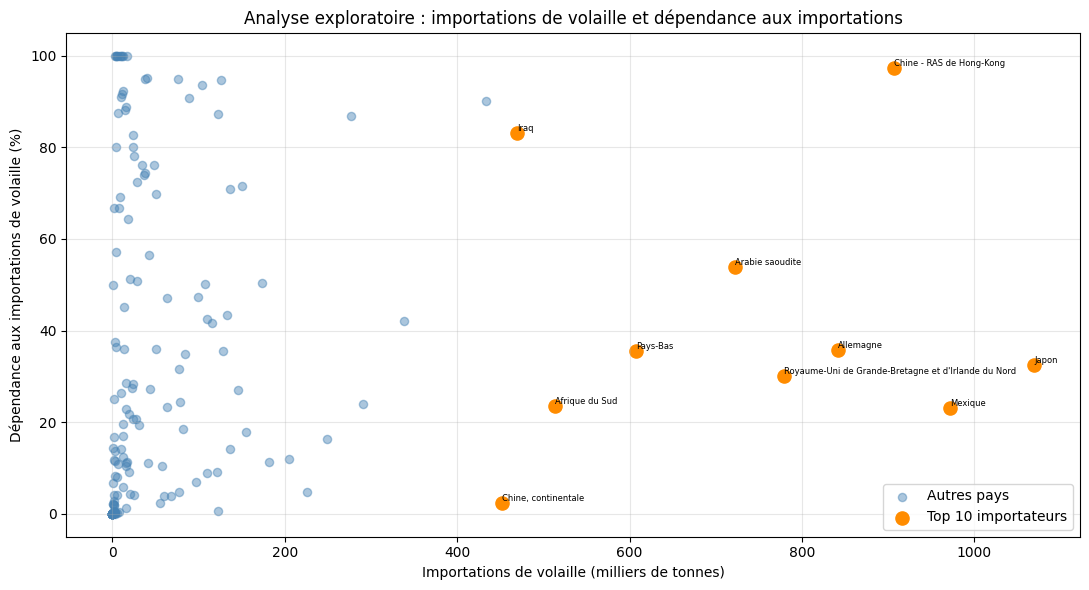

In [383]:
# Analyse exploratoire : importations de volaille et dépendance aux importations

plt.figure(figsize=(11, 6))

# Nuage de fond : tous les pays hors France
plt.scatter(
    base_marche_export["importations_volaille"],
    base_marche_export["dependance_importation_volaille"],
    alpha=0.45,
    s=35,
    color="steelblue",
    label="Autres pays")

# Sélection automatique des 10 pays avec les plus forts volumes d'importation, hors France
top_importateurs = (
    base_marche_export
    .sort_values("importations_volaille", ascending=False).head(10))

plt.scatter(
    top_importateurs["importations_volaille"],
    top_importateurs["dependance_importation_volaille"],
    s=90,
    color="darkorange",
    label="Top 10 importateurs")

for _, row in top_importateurs.iterrows():
    plt.text(
        row["importations_volaille"],
        row["dependance_importation_volaille"],
        row["pays"],
        fontsize=6,
        color="black",
        ha="left",
        va="bottom")

plt.xlabel("Importations de volaille (milliers de tonnes)")
plt.ylabel("Dépendance aux importations de volaille (%)")
plt.title("Analyse exploratoire : importations de volaille et dépendance aux importations")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Lecture du graphique : importations de volaille et dépendance aux importations

Ce graphique explore la relation entre deux dimensions importantes du marché de la volaille :

- le volume d’importations de volaille, qui donne une indication de la taille du marché importateur ;
- la dépendance aux importations, qui mesure le poids des importations dans l’approvisionnement total en volaille.

La France a été exclue de cette visualisation, car l’objectif du projet est d’identifier des marchés internationaux pour l’exportation d’une entreprise française.

À ce stade de l’analyse, les pays prioritaires ne sont pas encore identifiés. Les pays mis en évidence correspondent donc aux 10 principaux importateurs en volume, hors France, afin de mieux comprendre la structure du marché avant l’ACP, la classification et le score de priorisation.

On observe une forte hétérogénéité entre les pays. Une grande partie des pays présente des volumes d’importation faibles, tandis que quelques marchés concentrent des volumes beaucoup plus importants.

Le graphique montre aussi que le volume importé et la dépendance aux importations ne traduisent pas exactement la même réalité. Certains pays, comme Hong Kong ou l’Irak, présentent une forte dépendance aux importations. D’autres, comme le Japon, l’Allemagne, le Royaume-Uni ou les Pays-Bas, se distinguent surtout par des volumes d’importation élevés, avec une dépendance plus modérée.

Cette première lecture confirme que la taille du marché importateur ne suffit pas à elle seule pour recommander un pays. Elle doit être croisée avec d’autres dimensions : attractivité économique, qualité institutionnelle, performance logistique, droits de douane, coûts d’importation et dimension bio.

Cette logique justifie la suite de l’analyse : utiliser l’ACP pour synthétiser l’ensemble des variables, puis la classification et le score de priorisation pour identifier les marchés les plus pertinents.

## Analyse des corrélations entre les variables

Avant de réaliser l’ACP, les corrélations entre les variables quantitatives sont analysées afin d’identifier les relations fortes entre indicateurs et les éventuelles redondances.

Cette étape permet de mieux comprendre la structure des données avant la réduction de dimension.

In [384]:
# Matrice de corrélation entre les variables d'analyse

correlations = X.corr()

display(correlations.round(2))

,population_2017,dispo_kg_hab_volaille,importations_volaille,dependance_importation_volaille,production_kg_hab_volaille,pib_habitant_ppa,population_urbaine_pct,stabilite_politique,qualite_reglementaire,performance_logistique,droit_douane_poulet_moyen_pct,doing_business_score,score_cout_import_moyen,part_terres_arables_bio_pct
population_2017,1.00,-0.09,0.15,-0.22,0.00,-0.05,-0.04,-0.14,-0.03,0.15,0.12,-0.01,-0.07,-0.08
dispo_kg_hab_volaille,-0.09,1.00,0.18,0.11,0.57,0.43,0.38,0.44,0.44,0.34,-0.21,0.38,0.13,0.14
importations_volaille,0.15,0.18,1.00,0.10,0.11,0.36,0.36,0.09,0.34,0.47,-0.13,0.30,0.12,-0.01
dependance_importation_volaille,-0.22,0.11,0.10,1.00,-0.48,0.05,-0.03,0.26,-0.01,-0.13,-0.23,-0.13,-0.09,0.11
production_kg_hab_volaille,0.00,0.57,0.11,-0.48,1.00,0.38,0.47,0.25,0.42,0.43,-0.10,0.46,0.32,0.03
pib_habitant_ppa,-0.05,0.43,0.36,0.05,0.38,1.00,0.64,0.58,0.83,0.79,-0.47,0.70,0.46,0.26
population_urbaine_pct,-0.04,0.38,0.36,-0.03,0.47,0.64,1.00,0.35,0.55,0.53,-0.27,0.49,0.28,0.09
stabilite_politique,-0.14,0.44,0.09,0.26,0.25,0.58,0.35,1.00,0.72,0.55,-0.38,0.62,0.53,0.39
qualite_reglementaire,-0.03,0.44,0.34,-0.01,0.42,0.83,0.55,0.72,1.00,0.84,-0.46,0.88,0.61,0.33
performance_logistique,0.15,0.34,0.47,-0.13,0.43,0.79,0.53,0.55,0.84,1.00,-0.40,0.77,0.54,0.38


### Interprétation de la matrice de corrélation

La matrice de corrélation met en évidence plusieurs relations fortes entre les variables économiques, institutionnelles et logistiques.

Le PIB par habitant, la qualité réglementaire, la performance logistique, le score Doing Business et le score de coût d’importation sont positivement corrélés. Cela suggère l’existence d’une dimension commune liée au niveau de développement, à la qualité institutionnelle et à l’accessibilité opérationnelle des marchés.

À l’inverse, le droit de douane moyen appliqué au poulet est négativement corrélé avec plusieurs de ces indicateurs, ce qui indique que les pays les plus favorables sur le plan économique et logistique tendent aussi à présenter des barrières tarifaires plus faibles.

Les variables liées au marché avicole apportent une information complémentaire, notamment sur la consommation, la production locale et la dépendance aux importations.

Ces corrélations justifient l’utilisation de l’ACP afin de résumer les dimensions principales de l’analyse avant la classification des pays.

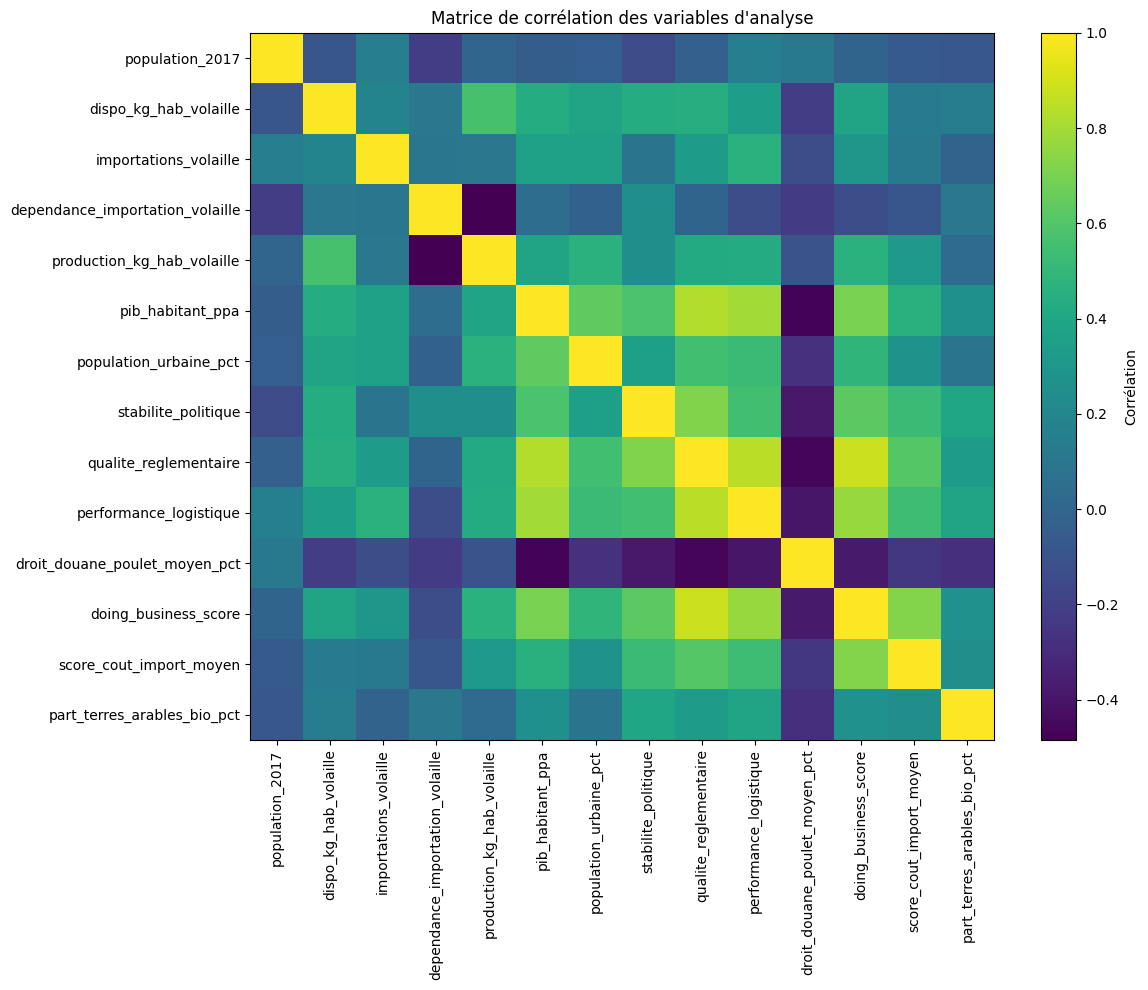

In [385]:
# Visualisation de la matrice de corrélation

plt.figure(figsize=(12, 10))
plt.imshow(correlations, aspect="auto")
plt.colorbar(label="Corrélation")

plt.xticks(
    ticks=range(len(correlations.columns)),
    labels=correlations.columns,
    rotation=90)

plt.yticks(
    ticks=range(len(correlations.columns)),
    labels=correlations.columns)

plt.title("Matrice de corrélation des variables d'analyse")
plt.tight_layout()
plt.show()

### Lecture du graphique de corrélation

Le graphique confirme visuellement l’existence d’un bloc de variables positivement corrélées, principalement autour du PIB par habitant, de la qualité réglementaire, de la performance logistique, du score Doing Business et du score de coût d’importation.

Les couleurs les plus claires indiquent des corrélations positives fortes entre ces indicateurs, ce qui traduit une dimension commune liée au niveau de développement, à la qualité institutionnelle et à l’accessibilité des marchés.

À l’inverse, les couleurs plus sombres observées autour du droit de douane moyen appliqué au poulet indiquent des corrélations négatives avec plusieurs variables d’attractivité. Cela signifie que les pays les plus favorables économiquement et logistiquement tendent à présenter des barrières tarifaires plus faibles.

Il convient toutefois de rappeler que ces corrélations traduisent des associations entre variables et ne permettent pas, à ce stade, d’établir une relation de causalité.

Cette structure de corrélations justifie l’utilisation de l’ACP afin de résumer l’information contenue dans les variables avant la classification des pays.

## Standardisation des variables

Les variables retenues présentent des unités et des ordres de grandeur différents : population, PIB par habitant, scores institutionnels, indicateurs logistiques ou droits de douane.

Avant de réaliser l’ACP et les classifications, les variables sont donc standardisées. Cette transformation permet de centrer chaque variable autour de 0 et de réduire son écart-type à 1.

Ainsi, chaque variable contribue à l’analyse sur une échelle comparable.

In [386]:
# Standardisation des variables d'analyse

scaler = StandardScaler()

X_standardise = scaler.fit_transform(X)

X_standardise = pd.DataFrame(
    X_standardise,
    columns=variables_analyse,
    index=base.index)

print("Dimensions de la matrice standardisée :", X_standardise.shape)

display(X_standardise.head())

print("\nMoyenne des variables standardisées :")
display(X_standardise.mean().round(2))

print("\nÉcart-type des variables standardisées :")
display(X_standardise.std().round(2))

Dimensions de la matrice standardisée : (163, 14)


,population_2017,dispo_kg_hab_volaille,importations_volaille,dependance_importation_volaille,production_kg_hab_volaille,pib_habitant_ppa,population_urbaine_pct,stabilite_politique,qualite_reglementaire,performance_logistique,droit_douane_poulet_moyen_pct,doing_business_score,score_cout_import_moyen,part_terres_arables_bio_pct
0,-0.05,-1.18,-0.32,0.46,-0.91,-0.92,-1.58,-2.90,-1.68,-1.74,-0.53,-1.72,-2.24,-0.49
1,0.08,0.99,2.25,-0.32,0.73,-0.33,0.21,-0.33,0.19,0.96,-0.15,0.28,-0.17,-0.49
2,-0.27,-0.24,-0.28,1.15,-0.69,-0.31,-0.13,0.30,0.05,-0.40,-0.53,0.19,1.08,-0.48
3,-0.02,-0.87,-0.47,-0.99,-0.57,-0.34,0.58,-0.96,-1.15,-0.79,0.57,-1.18,-0.71,-0.49
4,0.24,-0.04,3.98,0.03,0.10,1.78,1.03,0.92,1.85,2.51,-0.90,1.35,1.25,0.76



Moyenne des variables standardisées :


population_2017                   -0.00
dispo_kg_hab_volaille             -0.00
importations_volaille              0.00
dependance_importation_volaille   -0.00
production_kg_hab_volaille        -0.00
pib_habitant_ppa                   0.00
population_urbaine_pct            -0.00
stabilite_politique               -0.00
qualite_reglementaire              0.00
performance_logistique             0.00
droit_douane_poulet_moyen_pct      0.00
doing_business_score              -0.00
score_cout_import_moyen            0.00
part_terres_arables_bio_pct        0.00
dtype: float64


Écart-type des variables standardisées :


population_2017                   1.00
dispo_kg_hab_volaille             1.00
importations_volaille             1.00
dependance_importation_volaille   1.00
production_kg_hab_volaille        1.00
pib_habitant_ppa                  1.00
population_urbaine_pct            1.00
stabilite_politique               1.00
qualite_reglementaire             1.00
performance_logistique            1.00
droit_douane_poulet_moyen_pct     1.00
doing_business_score              1.00
score_cout_import_moyen           1.00
part_terres_arables_bio_pct       1.00
dtype: float64

In [387]:
# Exemple détaillé de standardisation pour l'Allemagne

pays_exemple = "DEU"
variable_exemple = "performance_logistique"

valeur_originale = base.loc[
    base["code_iso3"] == pays_exemple,
    variable_exemple].iloc[0]

moyenne_variable = X[variable_exemple].mean()
ecart_type_variable = X[variable_exemple].std(ddof=0)

valeur_standardisee_calculee = (
    valeur_originale - moyenne_variable) / ecart_type_variable

valeur_standardisee_sklearn = X_standardise.loc[
    base["code_iso3"] == pays_exemple,
    variable_exemple].iloc[0]

print("Pays :", base.loc[base["code_iso3"] == pays_exemple, "pays"].iloc[0])
print("Variable :", variable_exemple)
print("Valeur originale :", valeur_originale)
print("Moyenne de la variable :", moyenne_variable)
print("Écart-type de la variable :", ecart_type_variable)
print("Valeur standardisée calculée :", valeur_standardisee_calculee)
print("Valeur standardisée sklearn :", valeur_standardisee_sklearn)

Pays : Allemagne
Variable : performance_logistique
Valeur originale : 4.2
Moyenne de la variable : 2.8715030674846624
Écart-type de la variable : 0.5302841393022221
Valeur standardisée calculée : 2.5052548889420856
Valeur standardisée sklearn : 2.5052548889420856


In [388]:
# Comparaison des valeurs originales et standardisées pour l'Allemagne

pays_exemple = "DEU"

comparaison_allemagne = pd.DataFrame({
    "variable": variables_analyse,
    "valeur_originale": base.loc[
        base["code_iso3"] == pays_exemple,
        variables_analyse
    ].iloc[0].values,
    "moyenne_variable": X.mean().values,
    "ecart_type_variable": X.std(ddof=0).values,
    "valeur_standardisee": X_standardise.loc[
        base["code_iso3"] == pays_exemple,
        variables_analyse
    ].iloc[0].values})

comparaison_allemagne

,variable,valeur_originale,moyenne_variable,ecart_type_variable,valeur_standardisee
0,population_2017,"82,658,409.00","44,555,164.75","156,572,653.74",0.24
1,dispo_kg_hab_volaille,19.47,20.12,15.77,-0.04
2,importations_volaille,842.00,90.13,188.69,3.98
3,dependance_importation_volaille,35.74,34.80,34.58,0.03
4,production_kg_hab_volaille,18.32,16.55,17.41,0.10
5,pib_habitant_ppa,"54,110.25","20,000.01","19,151.05",1.78
6,population_urbaine_pct,80.98,58.81,21.54,1.03
7,stabilite_politique,0.70,-0.10,0.87,0.92
8,qualite_reglementaire,1.69,0.07,0.88,1.85
9,performance_logistique,4.20,2.87,0.53,2.51


In [389]:
pd.set_option("display.float_format", "{:,.2f}".format)

comparaison_allemagne

,variable,valeur_originale,moyenne_variable,ecart_type_variable,valeur_standardisee
0,population_2017,"82,658,409.00","44,555,164.75","156,572,653.74",0.24
1,dispo_kg_hab_volaille,19.47,20.12,15.77,-0.04
2,importations_volaille,842.00,90.13,188.69,3.98
3,dependance_importation_volaille,35.74,34.80,34.58,0.03
4,production_kg_hab_volaille,18.32,16.55,17.41,0.10
5,pib_habitant_ppa,"54,110.25","20,000.01","19,151.05",1.78
6,population_urbaine_pct,80.98,58.81,21.54,1.03
7,stabilite_politique,0.70,-0.10,0.87,0.92
8,qualite_reglementaire,1.69,0.07,0.88,1.85
9,performance_logistique,4.20,2.87,0.53,2.51


### Interprétation de la standardisation

La standardisation a permis de transformer les variables afin qu’elles aient toutes une moyenne proche de 0 et un écart-type proche de 1.

Cette étape est indispensable car les variables initiales présentent des unités et des ordres de grandeur très différents : population, PIB par habitant, scores institutionnels, indicateurs logistiques ou droits de douane.

Après standardisation, les valeurs ne correspondent plus aux valeurs originales, mais à la position relative de chaque pays par rapport à la moyenne de l’ensemble des pays. Une valeur positive indique un niveau supérieur à la moyenne, tandis qu’une valeur négative indique un niveau inférieur à la moyenne.

Cette transformation permet d’éviter qu’une variable à grande échelle numérique, comme la population ou le PIB, domine artificiellement l’ACP ou les classifications.

## Analyse en Composantes Principales (ACP)

L’Analyse en Composantes Principales est utilisée afin de résumer l’information contenue dans les variables quantitatives standardisées.

Elle permet de construire de nouveaux axes, appelés composantes principales, qui concentrent progressivement la variance des données.

Cette étape facilite la visualisation des pays et prépare la classification en groupes de pays présentant des profils similaires.

In [390]:
# Réalisation de l'ACP

pca = PCA()

coordonnees_acp = pca.fit_transform(X_standardise)

colonnes_acp = [
    "F" + str(i + 1)
    for i in range(coordonnees_acp.shape[1])]

coordonnees_acp = pd.DataFrame(
    coordonnees_acp,
    columns=colonnes_acp,
    index=base.index)

variance_expliquee = pd.DataFrame({
    "axe": colonnes_acp,
    "variance_expliquee_pct": pca.explained_variance_ratio_ * 100,
    "variance_cumulee_pct": np.cumsum(pca.explained_variance_ratio_) * 100})

display(variance_expliquee.round(2))

,axe,variance_expliquee_pct,variance_cumulee_pct
0,F1,41.54,41.54
1,F2,12.52,54.06
2,F3,8.99,63.05
3,F4,8.60,71.65
4,F5,6.08,77.73
5,F6,5.20,82.93
6,F7,4.76,87.68
7,F8,3.72,91.41
8,F9,2.81,94.22
9,F10,1.91,96.13


### Interprétation de la variance expliquée

Le premier axe de l’ACP explique 41,54 % de la variance totale, ce qui montre qu’une part importante de l’information est concentrée dans une première dimension principale.

Les deux premiers axes expliquent ensemble 54,06 % de la variance, ce qui permet une première visualisation pertinente des pays sur un plan factoriel.

Les quatre premiers axes expliquent 71,65 % de la variance totale, tandis que les six premiers axes en expliquent 82,93 %. Cela indique que l’ACP permet de réduire efficacement la dimension des données tout en conservant une part importante de l’information initiale.

L’interprétation précise des axes sera réalisée à partir des contributions des variables.

## Visualisation de la variance expliquée

La variance expliquée par chaque axe est représentée graphiquement afin d’identifier les axes qui concentrent le plus d’information.

La variance cumulée permet également d’évaluer le nombre d’axes à conserver pour la suite de l’analyse.

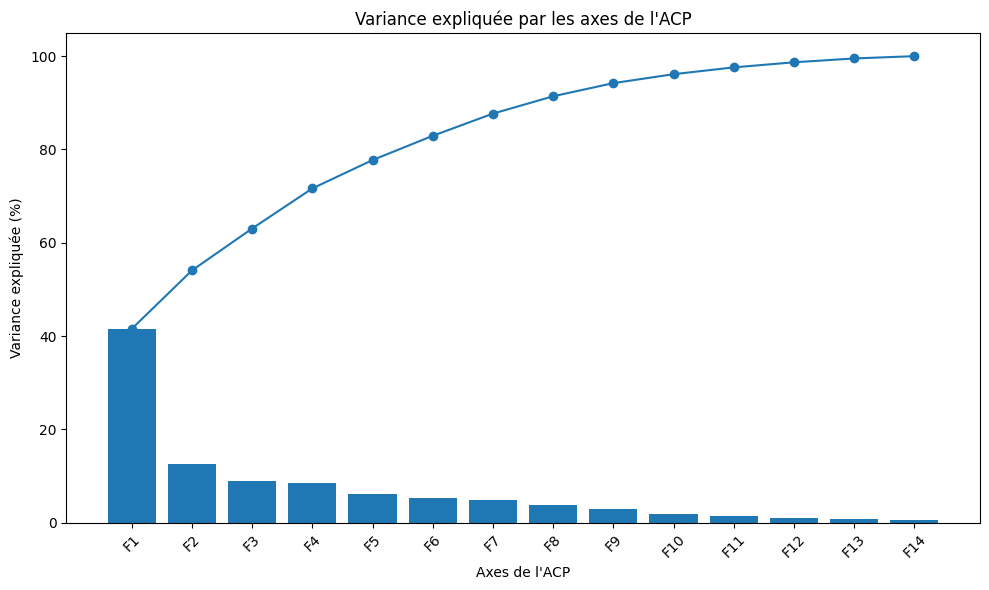

In [391]:
# Visualisation de la variance expliquée par les axes de l'ACP

plt.figure(figsize=(10, 6))

plt.bar(
    variance_expliquee["axe"],
    variance_expliquee["variance_expliquee_pct"])

plt.plot(
    variance_expliquee["axe"],
    variance_expliquee["variance_cumulee_pct"],
    marker="o")

plt.xlabel("Axes de l'ACP")
plt.ylabel("Variance expliquée (%)")
plt.title("Variance expliquée par les axes de l'ACP")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Lecture du graphique de variance expliquée

Le graphique montre que le premier axe de l’ACP concentre une part importante de l’information, avec 41,54 % de la variance totale expliquée.

Les deux premiers axes expliquent ensemble 54,06 % de la variance, ce qui permet une première visualisation pertinente des pays sur un plan factoriel.

La variance cumulée atteint 71,65 % avec les quatre premiers axes et 82,93 % avec les six premiers axes. Cela montre que l’ACP permet de réduire efficacement la dimension des données tout en conservant une part importante de l’information initiale.

À partir des axes F5/F6, le gain d’information devient progressivement plus faible. Le choix du nombre d’axes à conserver sera donc précisé après l’analyse des contributions des variables et en fonction de l’objectif de classification.

In [392]:
# Poids des variables dans les axes de l'ACP

poids_axes = pd.DataFrame(
    pca.components_.T,
    index=variables_analyse,
    columns=colonnes_acp)

display(poids_axes[["F1", "F2", "F3", "F4"]].round(3))

,F1,F2,F3,F4
population_2017,-0.02,-0.34,0.39,-0.41
dispo_kg_hab_volaille,0.23,-0.04,-0.06,0.57
importations_volaille,0.16,-0.10,0.67,0.04
dependance_importation_volaille,-0.01,0.62,0.30,0.20
production_kg_hab_volaille,0.23,-0.44,-0.28,0.32
pib_habitant_ppa,0.36,0.03,0.14,0.05
population_urbaine_pct,0.28,-0.13,0.19,0.30
stabilite_politique,0.31,0.27,-0.17,-0.01
qualite_reglementaire,0.39,0.03,0.00,-0.09
performance_logistique,0.37,-0.09,0.15,-0.21


In [393]:
# Exemple de calcul manuel de la coordonnée de l'Allemagne sur l'axe F1

pays_exemple = "DEU"
axe_exemple = "F1"

valeurs_standardisees_pays = X_standardise.loc[
    base["code_iso3"] == pays_exemple,
    variables_analyse].iloc[0]

poids_axe = poids_axes[axe_exemple]

detail_calcul = pd.DataFrame({
    "variable": variables_analyse,
    "valeur_standardisee_pays": valeurs_standardisees_pays.values,
    "poids_sur_axe": poids_axe.values,
    "produit": valeurs_standardisees_pays.values * poids_axe.values})

coordonnees_calculee = detail_calcul["produit"].sum()

coordonnees_python = coordonnees_acp.loc[
    base["code_iso3"] == pays_exemple,
    axe_exemple].iloc[0]

print("Pays :", base.loc[base["code_iso3"] == pays_exemple, "pays"].iloc[0])
print("Axe :", axe_exemple)
print("Coordonnée calculée manuellement :", coordonnees_calculee)
print("Coordonnée calculée par Python :", coordonnees_python)

display(detail_calcul.round(4))

Pays : Allemagne
Axe : F1
Coordonnée calculée manuellement : 4.662959892990419
Coordonnée calculée par Python : 4.662959892990419


,variable,valeur_standardisee_pays,poids_sur_axe,produit
0,population_2017,0.24,-0.02,-0.00
1,dispo_kg_hab_volaille,-0.04,0.23,-0.01
2,importations_volaille,3.98,0.16,0.65
3,dependance_importation_volaille,0.03,-0.01,-0.00
4,production_kg_hab_volaille,0.10,0.23,0.02
5,pib_habitant_ppa,1.78,0.36,0.64
6,population_urbaine_pct,1.03,0.28,0.28
7,stabilite_politique,0.92,0.31,0.28
8,qualite_reglementaire,1.85,0.39,0.72
9,performance_logistique,2.51,0.37,0.92


## Contribution des variables aux axes de l’ACP

L’interprétation des axes de l’ACP repose sur les variables qui contribuent le plus à leur construction.

Une contribution élevée signifie que la variable participe fortement à la définition de l’axe. Cette analyse permet de donner un sens métier aux composantes principales, par exemple en distinguant un axe lié à l’attractivité économique et logistique, ou un axe lié à la structure du marché avicole.

In [394]:
# Poids et contributions des variables aux axes de l'ACP

poids_axes = pd.DataFrame(
    pca.components_.T,
    index=variables_analyse,
    columns=colonnes_acp)

contributions_variables = (poids_axes ** 2) * 100

print("Poids des variables sur les 4 premiers axes :")
display(poids_axes[["F1", "F2", "F3", "F4"]].round(3))

print("\nContributions des variables sur les 4 premiers axes (%) :")
display(contributions_variables[["F1", "F2", "F3", "F4"]].round(2))

Poids des variables sur les 4 premiers axes :


,F1,F2,F3,F4
population_2017,-0.02,-0.34,0.39,-0.41
dispo_kg_hab_volaille,0.23,-0.04,-0.06,0.57
importations_volaille,0.16,-0.10,0.67,0.04
dependance_importation_volaille,-0.01,0.62,0.30,0.20
production_kg_hab_volaille,0.23,-0.44,-0.28,0.32
pib_habitant_ppa,0.36,0.03,0.14,0.05
population_urbaine_pct,0.28,-0.13,0.19,0.30
stabilite_politique,0.31,0.27,-0.17,-0.01
qualite_reglementaire,0.39,0.03,0.00,-0.09
performance_logistique,0.37,-0.09,0.15,-0.21



Contributions des variables sur les 4 premiers axes (%) :


,F1,F2,F3,F4
population_2017,0.03,11.54,14.99,16.75
dispo_kg_hab_volaille,5.23,0.13,0.37,32.29
importations_volaille,2.69,1.00,44.43,0.14
dependance_importation_volaille,0.00,39.06,9.01,3.82
production_kg_hab_volaille,5.24,19.45,7.96,10.11
pib_habitant_ppa,13.04,0.11,1.84,0.22
population_urbaine_pct,7.63,1.68,3.60,8.79
stabilite_politique,9.46,7.34,2.86,0.01
qualite_reglementaire,15.19,0.08,0.00,0.76
performance_logistique,13.36,0.87,2.13,4.51


In [395]:
# Principales variables contributrices pour chaque axe

for axe in ["F1", "F2", "F3", "F4"]:
    print("\n", axe)
    display(
        contributions_variables[axe]
        .sort_values(ascending=False)
        .head(6)
        .round(2))


 F1


qualite_reglementaire    15.19
doing_business_score     13.46
performance_logistique   13.36
pib_habitant_ppa         13.04
stabilite_politique       9.46
population_urbaine_pct    7.63
Name: F1, dtype: float64


 F2


dependance_importation_volaille   39.06
production_kg_hab_volaille        19.45
population_2017                   11.54
droit_douane_poulet_moyen_pct      9.58
part_terres_arables_bio_pct        8.70
stabilite_politique                7.34
Name: F2, dtype: float64


 F3


importations_volaille             44.43
population_2017                   14.99
dependance_importation_volaille    9.01
production_kg_hab_volaille         7.96
score_cout_import_moyen            7.08
part_terres_arables_bio_pct        4.53
Name: F3, dtype: float64


 F4


dispo_kg_hab_volaille         32.29
population_2017               16.75
score_cout_import_moyen       11.06
production_kg_hab_volaille    10.11
part_terres_arables_bio_pct    8.81
population_urbaine_pct         8.79
Name: F4, dtype: float64

In [396]:
# Variables les plus contributrices avec leur poids sur chaque axe

for axe in ["F1", "F2", "F3", "F4"]:
    print("\n", axe)
    
    interpretation_axe = pd.DataFrame({
        "poids": poids_axes[axe],
        "contribution_pct": contributions_variables[axe]})
    
    interpretation_axe["poids_abs"] = interpretation_axe["poids"].abs()
    
    display(
        interpretation_axe
        .sort_values("contribution_pct", ascending=False)
        .head(8)
        .drop(columns="poids_abs")
        .round(3))


 F1


,poids,contribution_pct
qualite_reglementaire,0.39,15.19
doing_business_score,0.37,13.46
performance_logistique,0.37,13.36
pib_habitant_ppa,0.36,13.04
stabilite_politique,0.31,9.46
population_urbaine_pct,0.28,7.63
score_cout_import_moyen,0.27,7.51
production_kg_hab_volaille,0.23,5.24



 F2


,poids,contribution_pct
dependance_importation_volaille,0.62,39.06
production_kg_hab_volaille,-0.44,19.45
population_2017,-0.34,11.54
droit_douane_poulet_moyen_pct,-0.31,9.58
part_terres_arables_bio_pct,0.29,8.70
stabilite_politique,0.27,7.34
population_urbaine_pct,-0.13,1.68
importations_volaille,-0.10,1.00



 F3


,poids,contribution_pct
importations_volaille,0.67,44.43
population_2017,0.39,14.99
dependance_importation_volaille,0.30,9.01
production_kg_hab_volaille,-0.28,7.96
score_cout_import_moyen,-0.27,7.08
part_terres_arables_bio_pct,-0.21,4.53
population_urbaine_pct,0.19,3.60
stabilite_politique,-0.17,2.86



 F4


,poids,contribution_pct
dispo_kg_hab_volaille,0.57,32.29
population_2017,-0.41,16.75
score_cout_import_moyen,-0.33,11.06
production_kg_hab_volaille,0.32,10.11
part_terres_arables_bio_pct,-0.30,8.81
population_urbaine_pct,0.30,8.79
performance_logistique,-0.21,4.51
dependance_importation_volaille,0.20,3.82


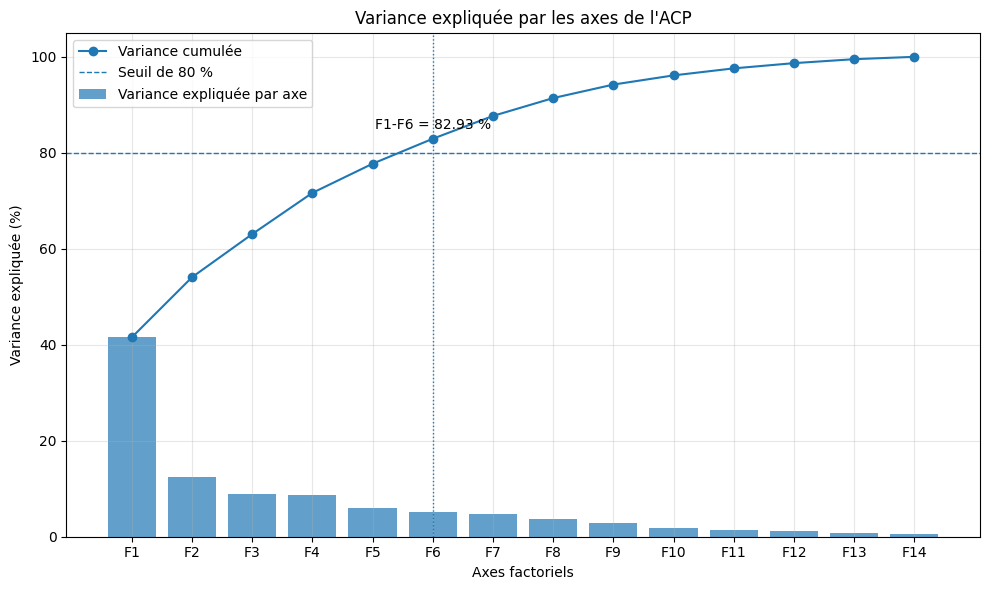

In [397]:
# Éboulis des valeurs propres / variance expliquée par les axes de l'ACP

# Récupération propre de la variance expliquée depuis l'objet PCA
variance_expliquee = np.array(pca.explained_variance_ratio_).ravel()
variance_cumulee = np.cumsum(variance_expliquee)

# Création d'un tableau avec la variance expliquée
variance_df = pd.DataFrame({
    "axe": [f"F{i+1}" for i in range(len(variance_expliquee))],
    "variance_expliquee_pct": variance_expliquee * 100,
    "variance_cumulee_pct": variance_cumulee * 100})

plt.figure(figsize=(10, 6))

# Barres : variance expliquée par axe
plt.bar(
    variance_df["axe"],
    variance_df["variance_expliquee_pct"],
    alpha=0.7,
    label="Variance expliquée par axe")

# Courbe : variance cumulée
plt.plot(
    variance_df["axe"],
    variance_df["variance_cumulee_pct"],
    marker="o",
    label="Variance cumulée")

# Ligne de seuil à 80 %
plt.axhline(
    y=80,
    linestyle="--",
    linewidth=1,
    label="Seuil de 80 %")

# Mise en évidence du choix F1-F6
plt.axvline(
    x=5,
    linestyle=":",
    linewidth=1)

plt.text(
    5,
    variance_df.loc[5, "variance_cumulee_pct"] + 2,
    f"F1-F6 = {variance_df.loc[5, 'variance_cumulee_pct']:.2f} %",
    ha="center",
    fontsize=10)

plt.xlabel("Axes factoriels")
plt.ylabel("Variance expliquée (%)")
plt.title("Variance expliquée par les axes de l'ACP")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interprétation des premiers axes de l’ACP

L’analyse des poids et des contributions des variables permet de donner un sens aux premiers axes de l’ACP.

Le premier axe est principalement construit par la qualité réglementaire, le score Doing Business, la performance logistique, le PIB par habitant, la stabilité politique, la population urbaine et le score de coût d’importation. Ces variables ayant des poids positifs, l’axe F1 peut être interprété comme un axe d’attractivité économique, institutionnelle et logistique. Les pays situés du côté positif de cet axe présentent donc un environnement plus favorable à une activité d’exportation.

Le deuxième axe oppose principalement la dépendance aux importations de volaille à la production locale par habitant, à la population et aux droits de douane. Il peut être interprété comme un axe de structure du marché avicole. Les pays situés du côté positif de F2 sont davantage dépendants des importations, avec une production locale plus limitée.

Le troisième axe est dominé par les importations de volaille, la population et la dépendance aux importations. Il représente principalement une dimension de volume d’importation et de taille du marché. Les pays situés du côté positif de cet axe correspondent à de grands marchés importateurs de volaille.

Le quatrième axe est principalement lié à la disponibilité de volaille par habitant, à la production locale par habitant et à l’urbanisation. Il apporte une lecture complémentaire du profil de consommation et du marché intérieur.

Ces quatre axes permettent donc de résumer plusieurs dimensions importantes pour l’analyse : l’attractivité générale des pays, leur dépendance aux importations, la taille du marché importateur et le profil de consommation de volaille.

In [398]:
# Variables les plus contributrices pour F5 et F6

for axe in ["F5", "F6"]:
    print("\n", axe)
    
    interpretation_axe = pd.DataFrame({
        "poids": poids_axes[axe],
        "contribution_pct": contributions_variables[axe]})
    
    display(
        interpretation_axe
        .assign(poids_abs=lambda df: df["poids"].abs())
        .sort_values("contribution_pct", ascending=False)
        .head(8)
        .drop(columns="poids_abs")
        .round(3))


 F5


,poids,contribution_pct
part_terres_arables_bio_pct,0.56,31.69
population_2017,0.51,25.67
dispo_kg_hab_volaille,0.41,16.59
score_cout_import_moyen,-0.38,14.19
doing_business_score,-0.18,3.30
importations_volaille,-0.15,2.20
production_kg_hab_volaille,0.14,2.04
population_urbaine_pct,-0.13,1.76



 F6


,poids,contribution_pct
droit_douane_poulet_moyen_pct,0.63,39.88
stabilite_politique,0.37,13.81
dependance_importation_volaille,0.32,10.18
dispo_kg_hab_volaille,0.30,9.14
score_cout_import_moyen,0.26,6.73
population_2017,0.24,5.80
population_urbaine_pct,-0.23,5.50
part_terres_arables_bio_pct,-0.20,4.03


In [399]:
# Préparation des objets nécessaires pour les visualisations ACP

df = base
X_scaled = X_standardise
coord_pays = coordonnees_acp

variables_quantitatives = list(X.columns)

print("df :", df.shape)
print("X_scaled :", X_scaled.shape)
print("coord_pays :", coord_pays.shape)
print("Nombre de variables quantitatives :", len(variables_quantitatives))

df : (163, 30)
X_scaled : (163, 14)
coord_pays : (163, 14)
Nombre de variables quantitatives : 14


In [400]:
# Coordonnées des variables pour le cercle des corrélations

eigval = pca.explained_variance_

coord_variables = pd.DataFrame(
    pca.components_.T * np.sqrt(eigval),
    columns=[f"F{i+1}" for i in range(pca.n_components_)],
    index=variables_quantitatives)

coord_variables.head(15)

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14
population_2017,-0.04,-0.45,0.44,-0.45,0.47,0.21,-0.34,0.12,0.12,-0.02,0.00,0.00,-0.04,0.01
dispo_kg_hab_volaille,0.55,-0.05,-0.07,0.63,0.38,0.26,-0.05,-0.19,-0.00,-0.16,0.07,-0.15,0.06,0.00
importations_volaille,0.40,-0.13,0.75,0.04,-0.14,0.03,0.33,-0.33,0.07,0.13,-0.01,-0.04,-0.06,0.01
dependance_importation_volaille,-0.02,0.83,0.34,0.22,0.00,0.27,-0.07,0.06,0.14,-0.11,-0.06,0.20,0.00,-0.00
production_kg_hab_volaille,0.55,-0.59,-0.32,0.35,0.13,-0.05,-0.00,-0.11,0.14,0.09,-0.15,0.21,-0.06,0.01
pib_habitant_ppa,0.87,0.04,0.15,0.05,-0.05,-0.12,-0.03,0.17,-0.24,-0.18,-0.21,-0.07,-0.16,-0.04
population_urbaine_pct,0.67,-0.17,0.21,0.33,-0.12,-0.20,0.08,0.48,0.27,0.03,0.10,-0.04,0.04,0.00
stabilite_politique,0.74,0.36,-0.19,-0.01,0.07,0.32,-0.10,0.11,-0.06,0.38,-0.05,-0.08,-0.01,-0.04
qualite_reglementaire,0.94,0.04,0.00,-0.10,-0.06,0.04,-0.04,0.02,-0.19,-0.00,0.11,0.07,-0.01,0.21
performance_logistique,0.88,-0.12,0.16,-0.23,0.07,-0.06,0.09,-0.01,-0.15,-0.03,-0.11,0.07,0.26,-0.05


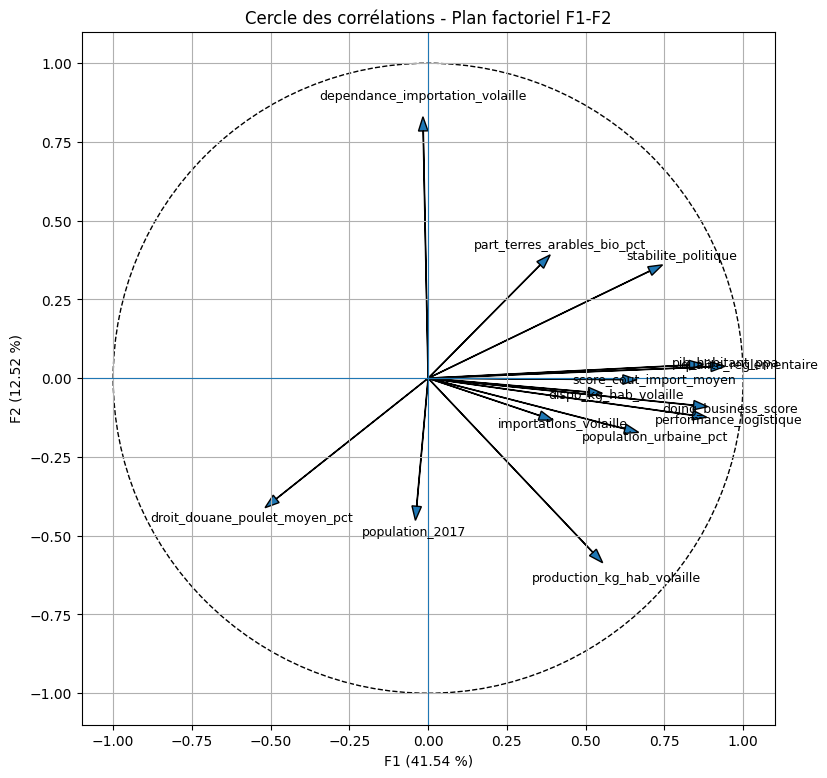

In [401]:
# Cercle des corrélations - Plan F1-F2

fig, ax = plt.subplots(figsize=(9, 9))

# Cercle unité
cercle = plt.Circle((0, 0), 1, fill=False, linestyle="--")
ax.add_artist(cercle)

# Axes
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

# Flèches des variables
for var in coord_variables.index:
    x = coord_variables.loc[var, "F1"]
    y = coord_variables.loc[var, "F2"]
    
    ax.arrow(
        0, 0, x, y,
        head_width=0.03,
        length_includes_head=True    )
    
    ax.text(
        x * 1.08,
        y * 1.08,
        var,
        fontsize=9,
        ha="center",
        va="center")

# Mise en forme
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect("equal")

ax.set_xlabel(f"F1 ({pca.explained_variance_ratio_[0]*100:.2f} %)")
ax.set_ylabel(f"F2 ({pca.explained_variance_ratio_[1]*100:.2f} %)")

ax.set_title("Cercle des corrélations - Plan factoriel F1-F2")
ax.grid(True)

plt.show()

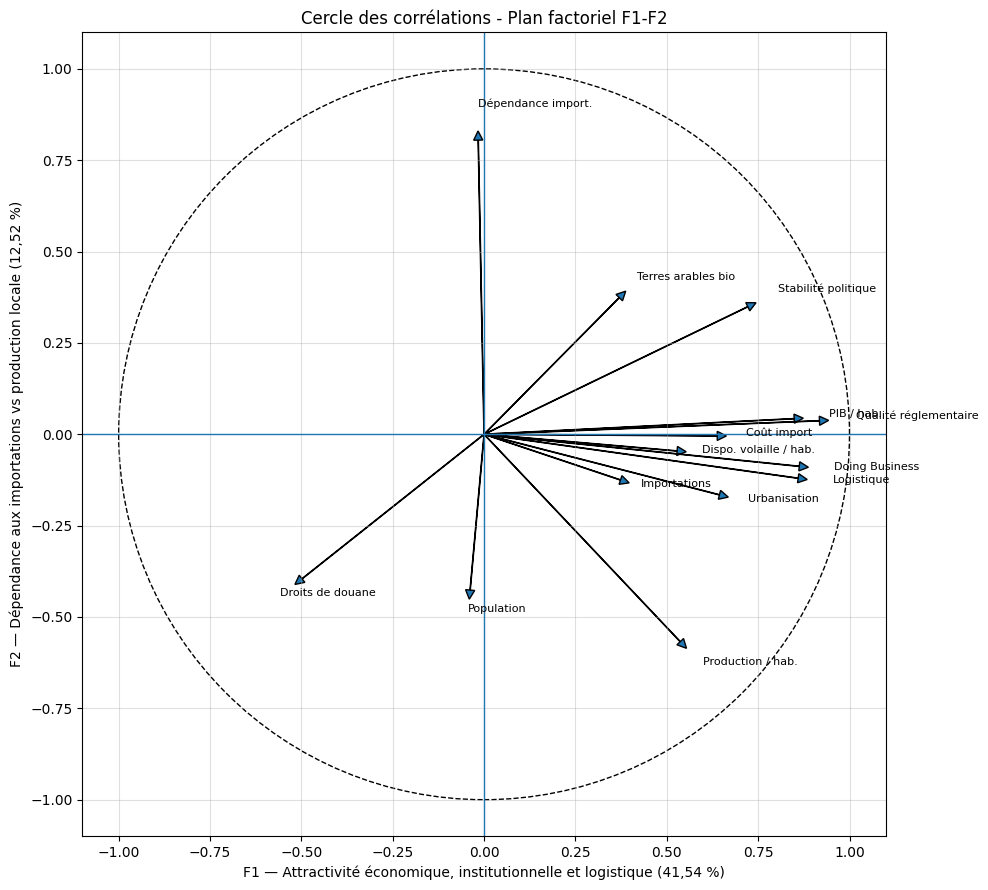

In [402]:
# Cercle des corrélations F1-F2 - version lisible

coord_variables = pd.DataFrame(
    pca.components_.T * np.sqrt(pca.explained_variance_),
    columns=[f"F{i+1}" for i in range(pca.n_components_)],
    index=variables_quantitatives)

labels_courts = {
    "dependance_importation_volaille": "Dépendance import.",
    "droit_douane_poulet_moyen_pct": "Droits de douane",
    "production_kg_hab_volaille": "Production / hab.",
    "population_2017": "Population",
    "part_terres_arables_bio_pct": "Terres arables bio",
    "stabilite_politique": "Stabilité politique",
    "pib_habitant_ppa": "PIB / hab.",
    "performance_logistique": "Logistique",
    "doing_business_score": "Doing Business",
    "qualite_reglementaire": "Qualité réglementaire",
    "population_urbaine_pct": "Urbanisation",
    "score_cout_import_moyen": "Coût import",
    "dispo_kg_hab_volaille": "Dispo. volaille / hab.",
    "importations_volaille": "Importations",
    "production_volaille": "Production"}

plt.figure(figsize=(11, 9))
ax = plt.gca()

# Cercle unité
cercle = plt.Circle((0, 0), 1, fill=False, linestyle="--", linewidth=1)
ax.add_artist(cercle)

# Axes
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

texts = []

for variable in coord_variables.index:
    x = coord_variables.loc[variable, "F1"]
    y = coord_variables.loc[variable, "F2"]
    
    plt.arrow(
        0, 0, x, y,
        head_width=0.025,
        head_length=0.025,
        length_includes_head=True,
        linewidth=1)
    
    label = labels_courts.get(variable, variable)
    
    texts.append(
        plt.text(
            x * 1.08,
            y * 1.08,
            label,
            fontsize=8))

# Ajustement automatique des labels si adjustText est disponible
try:
    from adjustText import adjust_text
    
    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="-", linewidth=0.5))
except ImportError:
    pass

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

plt.xlabel("F1 — Attractivité économique, institutionnelle et logistique (41,54 %)")
plt.ylabel("F2 — Dépendance aux importations vs production locale (12,52 %)")

plt.title("Cercle des corrélations - Plan factoriel F1-F2")
plt.grid(True, alpha=0.4)
plt.gca().set_aspect("equal", adjustable="box")
plt.tight_layout()

plt.show()

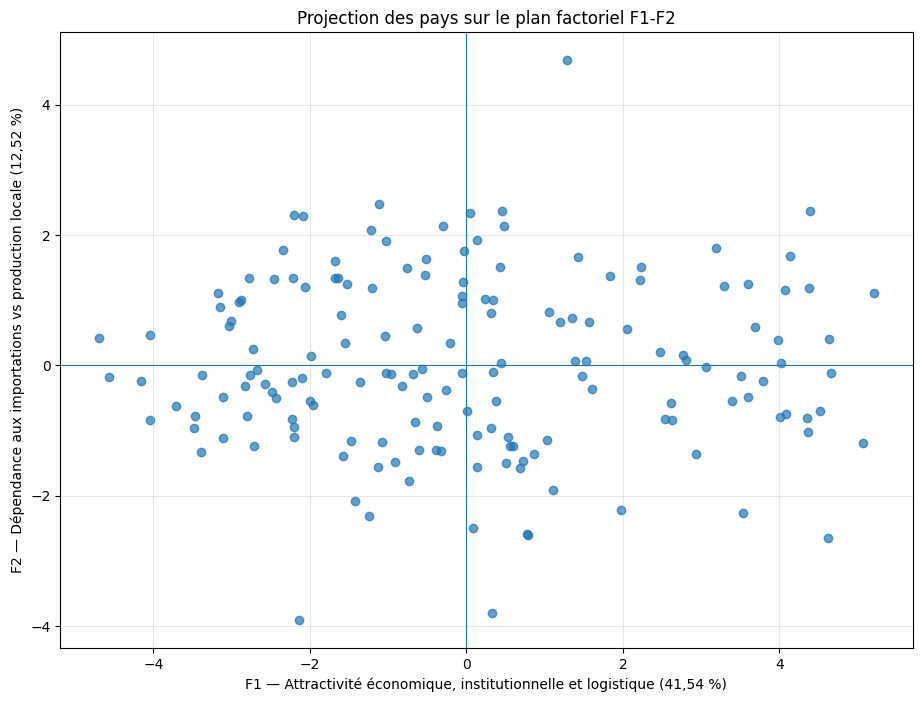

In [403]:
# Projection des pays sur le plan factoriel F1-F2

plt.figure(figsize=(11, 8))

plt.scatter(
    coord_pays["F1"],
    coord_pays["F2"],
    alpha=0.7)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.title("Projection des pays sur le plan factoriel F1-F2")
plt.xlabel("F1 — Attractivité économique, institutionnelle et logistique (41,54 %)")
plt.ylabel("F2 — Dépendance aux importations vs production locale (12,52 %)")

plt.grid(True, alpha=0.3)
plt.show()

In [404]:
# Ajout du nom des pays aux coordonnées ACP

coord_pays = coord_pays.copy()

if "pays" not in coord_pays.columns:
    coord_pays["pays"] = df["pays"].values

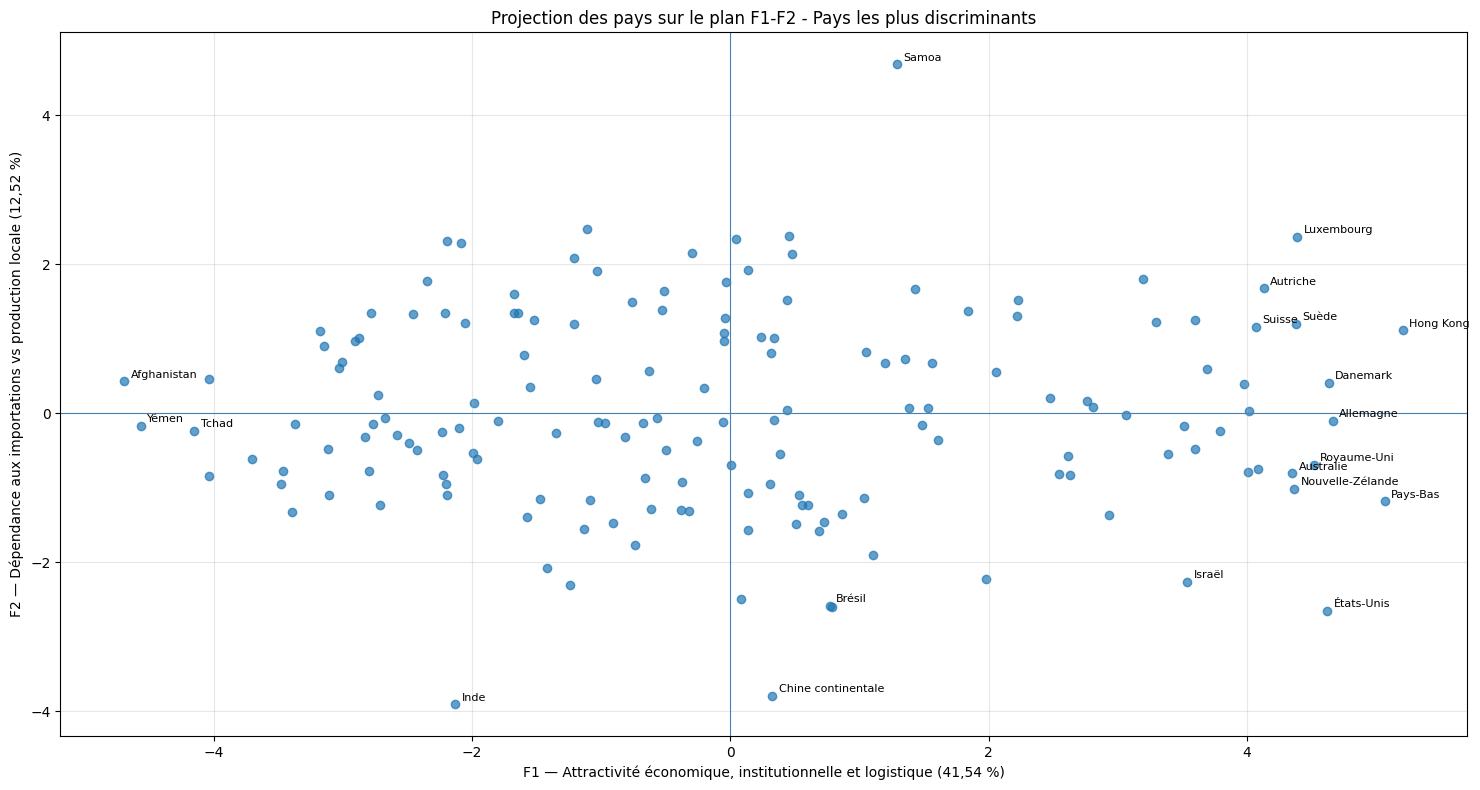

In [405]:
# Projection des pays sur le plan F1-F2
# Pays les plus discriminants + Brésil et Chine continentale

import matplotlib.pyplot as plt
import pandas as pd

# Nom de la colonne pays
col_pays = "pays"

# Copie de sécurité
coord_pays_graph = coord_pays.copy()

# Si les colonnes F1 / F2 ne sont pas déjà nommées
if "F1" not in coord_pays_graph.columns or "F2" not in coord_pays_graph.columns:
    nouvelles_colonnes = [f"F{i+1}" for i in range(coord_pays_graph.shape[1])]
    coord_pays_graph.columns = nouvelles_colonnes

# Ajout de la colonne pays si elle n'existe pas encore dans coord_pays_graph
if col_pays not in coord_pays_graph.columns:
    
    if "base_cluster" in globals() and col_pays in base_cluster.columns:
        if len(base_cluster) == len(coord_pays_graph):
            coord_pays_graph[col_pays] = base_cluster[col_pays].values
        else:
            raise ValueError(
                "base_cluster existe, mais sa taille ne correspond pas à coord_pays_graph.")
    
    elif "df" in globals() and col_pays in df.columns:
        if len(df) == len(coord_pays_graph):
            coord_pays_graph[col_pays] = df[col_pays].values
        else:
            raise ValueError(
                "df existe, mais sa taille ne correspond pas à coord_pays_graph.")
    
    else:
        raise ValueError(
            "Impossible de retrouver la colonne 'pays'. "
            "Vérifie que 'base_cluster' ou 'df' contient bien la colonne pays.")

# Calcul de la distance au centre sur le plan F1-F2
coord_pays_graph["distance_F1_F2"] = (
    coord_pays_graph["F1"]**2 + coord_pays_graph["F2"]**2) ** 0.5

# Pays les plus discriminants
pays_discriminants = (
    coord_pays_graph
    .sort_values("distance_F1_F2", ascending=False)
    .head(18)[col_pays]
    .tolist())

# Ajout explicite des pays demandés
pays_a_annoter = list(dict.fromkeys(
    pays_discriminants + ["Brésil", "Chine, continentale"]))

# Labels plus lisibles
labels_affichage = {
    "Chine, continentale": "Chine continentale",
    "Chine - RAS de Hong-Kong": "Hong Kong",
    "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord": "Royaume-Uni",
    "États-Unis d'Amérique": "États-Unis"}

# Graphique
plt.figure(figsize=(15, 8))

# Nuage principal
plt.scatter(
    coord_pays_graph["F1"],
    coord_pays_graph["F2"],
    alpha=0.7)

# Axes
plt.axhline(0, color="steelblue", linewidth=0.8)
plt.axvline(0, color="steelblue", linewidth=0.8)

# Annotation des pays sélectionnés
for pays in pays_a_annoter:
    ligne = coord_pays_graph[coord_pays_graph[col_pays] == pays]

    if not ligne.empty:
        x = ligne["F1"].values[0]
        y = ligne["F2"].values[0]

        plt.text(
            x + 0.05,
            y + 0.05,
            labels_affichage.get(pays, pays),
            fontsize=8)

# Titres et axes
plt.title("Projection des pays sur le plan F1-F2 - Pays les plus discriminants")
plt.xlabel("F1 — Attractivité économique, institutionnelle et logistique (41,54 %)")
plt.ylabel("F2 — Dépendance aux importations vs production locale (12,52 %)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Le plan factoriel F1-F2 met en évidence plusieurs profils de pays.

Les pays situés à droite du graphique présentent des scores élevés sur l’axe F1, associé à l’attractivité économique, institutionnelle et logistique. On y retrouve notamment Hong Kong, l’Allemagne, les Pays-Bas, le Danemark, le Royaume-Uni, les États-Unis ou encore le Luxembourg. Ces pays apparaissent donc comme des marchés structurellement plus favorables.

À l’inverse, les pays situés à gauche, comme l’Afghanistan ou le Yémen, présentent un profil moins favorable sur cet axe, ce qui peut traduire davantage de contraintes économiques, institutionnelles ou logistiques.

L’axe F2 permet de différencier les pays selon leur profil d’approvisionnement en volaille. Les pays situés en haut du graphique sont davantage associés à la dépendance aux importations, tandis que les pays situés en bas sont plus proches d’un profil orienté vers la production locale ou de marchés atypiques.

Le Brésil, ajouté sur le graphique, illustre un profil davantage lié à la production locale. La Chine continentale et l’Inde apparaissent comme des méga-marchés atypiques, distincts des marchés prioritaires identifiés ensuite.

Cette projection permet donc d’identifier les grandes oppositions entre pays, mais elle ne suffit pas à elle seule à sélectionner les marchés prioritaires. La prochaine étape consiste à réaliser une classification afin d’identifier des groupes de pays homogènes.

Le Brésil et la Chine continentale apparaissent dans la partie basse du graphique. Cette position traduit un profil davantage associé à la production locale et à une plus faible dépendance aux importations de volaille. Même si ces pays présentent une certaine attractivité structurelle sur l’axe F1, ils ne constituent pas les marchés les plus pertinents pour une stratégie d’exportation, car leur besoin d’importation apparaît plus limité.

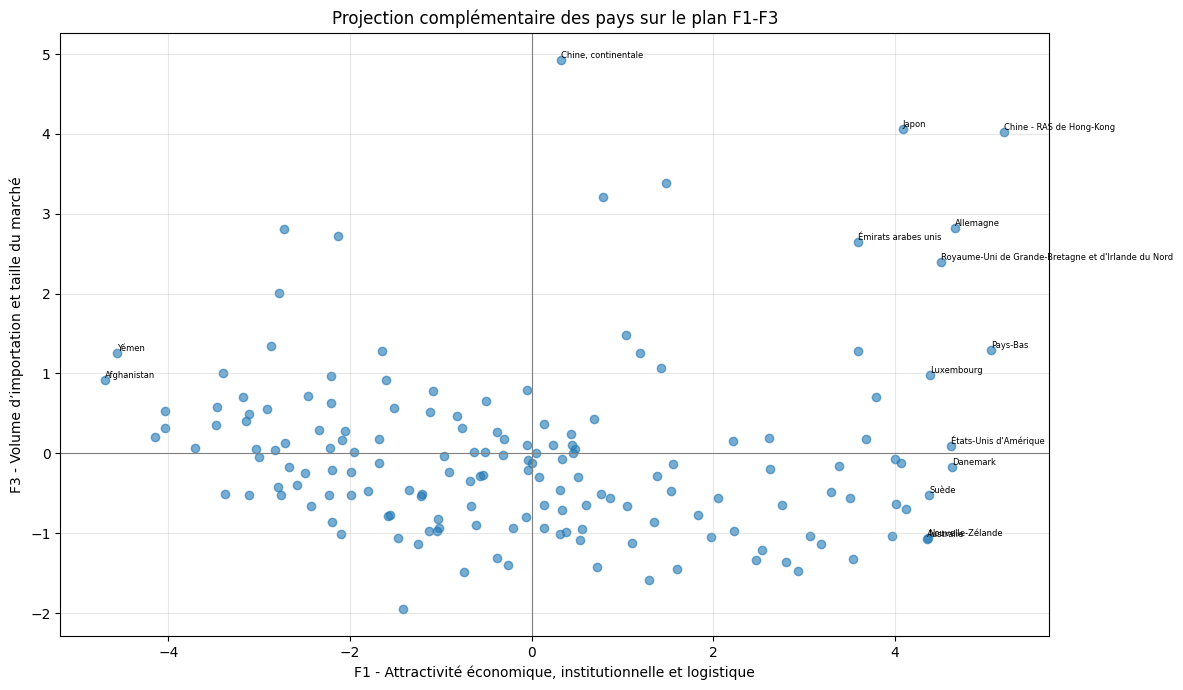

In [406]:
# Projection complémentaire des pays sur le plan F1-F3

coord_plot = coord_pays.copy()

# Ajout du nom des pays à partir de la base principale
# On suppose que coord_pays et base ont le même ordre de lignes
coord_plot["pays"] = base["pays"].values

# Sélection des pays les plus éloignés du centre sur le plan F1-F3
coord_plot["distance_F1_F3"] = (
    coord_plot["F1"]**2 + coord_plot["F3"]**2) ** 0.5

pays_a_afficher = (
    coord_plot
    .sort_values("distance_F1_F3", ascending=False).head(15))

plt.figure(figsize=(12, 7))

plt.scatter(
    coord_plot["F1"],
    coord_plot["F3"],
    alpha=0.6)

plt.axhline(0, color="grey", linewidth=0.8)
plt.axvline(0, color="grey", linewidth=0.8)

for _, row in pays_a_afficher.iterrows():
    plt.text(
        row["F1"],
        row["F3"],
        row["pays"],
        fontsize=6,
        ha="left",
        va="bottom")

plt.xlabel("F1 - Attractivité économique, institutionnelle et logistique")
plt.ylabel("F3 - Volume d’importation et taille du marché")
plt.title("Projection complémentaire des pays sur le plan F1-F3")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Projection complémentaire sur le plan F1-F3

Cette projection complémentaire permet d’observer les pays selon F1 et F3.

Le plan F1-F2 reste la visualisation principale de l’ACP, car il explique la plus grande part de variance en deux dimensions et offre une lecture plus synthétique des profils de pays. Cependant, F3 apporte une information complémentaire liée au volume d’importation et à la taille du marché.

Sur ce graphique, l’axe F1 distingue principalement les pays selon leur attractivité économique, institutionnelle et logistique. L’axe F3 met davantage en évidence les pays caractérisés par un volume d’importation important ou une taille de marché significative.

Les pays affichés correspondent aux pays les plus éloignés du centre sur le plan F1-F3. Ils sont donc les plus discriminants sur cette projection.

Cette visualisation confirme que l’analyse ne se limite pas au plan F1-F2 : les six premiers axes de l’ACP sont ensuite utilisés pour la classification, afin de conserver 82,93 % de la variance totale.

## Choix des axes retenus pour la classification

Le plan factoriel F1-F2 est utilisé pour visualiser les principales oppositions entre les pays. Il résume 54,06 % de l’information totale, ce qui permet une lecture synthétique des profils de pays.

Cependant, pour la classification, utiliser uniquement les deux premiers axes conduirait à perdre une part importante de l’information. Afin de conserver une représentation plus complète des pays tout en réduisant la dimensionnalité des données, la classification sera réalisée à partir des six premiers axes de l’ACP.

Les six premiers axes factoriels expliquent 82,93 % de la variance totale. Ce choix permet donc de conserver l’essentiel de l’information disponible, tout en évitant de travailler directement sur les 14 variables initiales.

In [407]:
# Sélection des axes factoriels retenus pour la classification

axes_clustering = ["F1", "F2", "F3", "F4", "F5", "F6"]

X_clustering = coord_pays[axes_clustering]

print("Axes retenus pour la classification :", axes_clustering)
print("Dimension de la base utilisée pour la classification :", X_clustering.shape)

X_clustering.head()

Axes retenus pour la classification : ['F1', 'F2', 'F3', 'F4', 'F5', 'F6']
Dimension de la base utilisée pour la classification : (163, 6)


,F1,F2,F3,F4,F5,F6
0,-4.70,0.43,0.92,0.35,0.36,-1.76
1,1.04,-1.14,1.49,0.76,-0.01,0.07
2,-0.04,1.28,-0.08,-0.25,-0.93,0.55
3,-2.22,-0.83,0.07,0.13,-0.34,-0.89
4,4.66,-0.11,2.83,-1.11,-0.79,-0.25


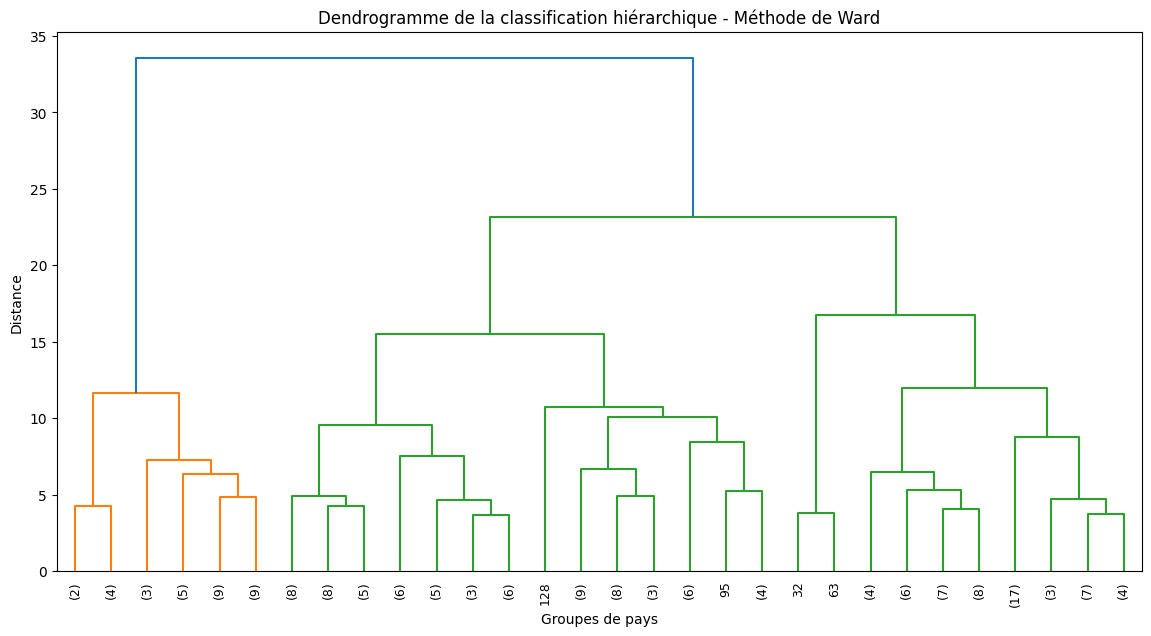

In [408]:
# CAH - Dendrogramme avec la méthode de Ward

from scipy.cluster.hierarchy import linkage, dendrogram

# Calcul de la matrice de liaison à partir des 6 premiers axes de l'ACP
Z = linkage(X_clustering, method="ward")

# Affichage du dendrogramme
plt.figure(figsize=(14, 7))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=9)

plt.title("Dendrogramme de la classification hiérarchique - Méthode de Ward")
plt.xlabel("Groupes de pays")
plt.ylabel("Distance")

plt.show()

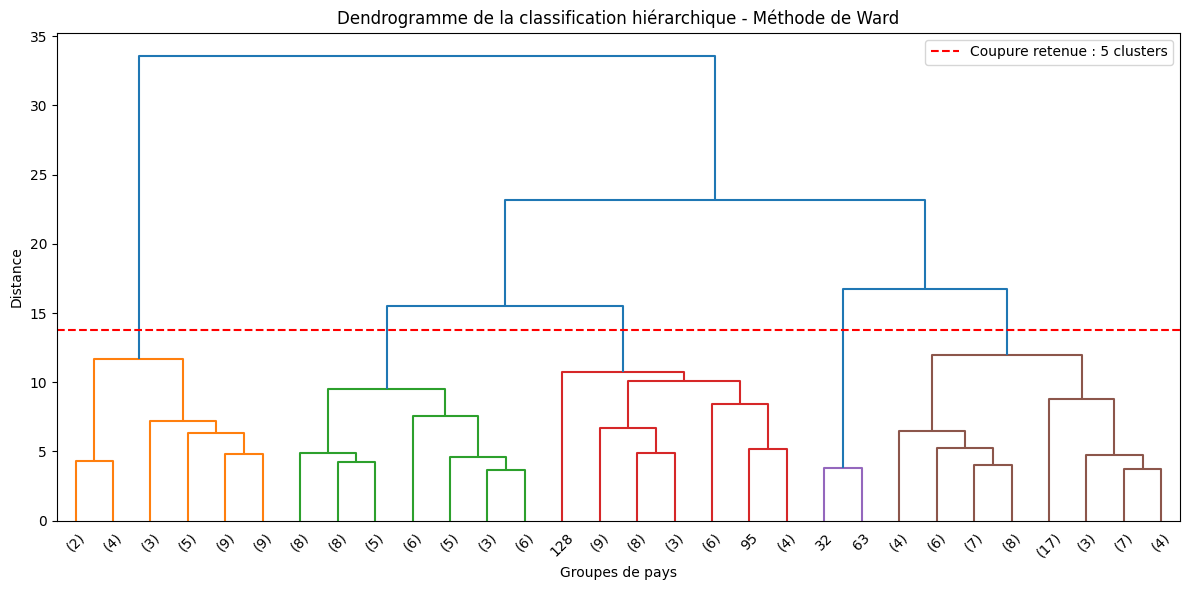

In [409]:
# Dendrogramme avec ligne de coupure pour 5 clusters

k = 5

# Seuil de coupure entre la solution à 5 clusters et la solution à 4 clusters
seuil_coupure = (Z[-k, 2] + Z[-(k-1), 2]) / 2

plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    color_threshold=seuil_coupure)

plt.axhline(
    y=seuil_coupure,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Coupure retenue : {k} clusters")

plt.title("Dendrogramme de la classification hiérarchique - Méthode de Ward")
plt.xlabel("Groupes de pays")
plt.ylabel("Distance")
plt.legend()
plt.tight_layout()
plt.show()

In [410]:
# Évaluation du nombre de clusters avec le score de silhouette

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

scores_silhouette = []

for k in range(2, 9):
    modele_cah = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward")
    
    labels = modele_cah.fit_predict(X_clustering)
    
    score = silhouette_score(X_clustering, labels)
    
    scores_silhouette.append({
        "Nombre de clusters": k,
        "Score de silhouette": score})

scores_silhouette = pd.DataFrame(scores_silhouette)

scores_silhouette

,Nombre de clusters,Score de silhouette
0,2,0.33
1,3,0.23
2,4,0.24
3,5,0.25
4,6,0.23
5,7,0.23
6,8,0.23


In [411]:
# Création des clusters avec la CAH

nombre_clusters_cah = 5

modele_cah_final = AgglomerativeClustering(
    n_clusters=nombre_clusters_cah,
    linkage="ward")

labels_cah = modele_cah_final.fit_predict(X_clustering)

# Ajout des clusters à la base
base_cluster = base.copy()
base_cluster["cluster_cah"] = labels_cah + 1

# Vérification de la taille des clusters
base_cluster["cluster_cah"].value_counts().sort_index()

cluster_cah
1    56
2    32
3    32
4     2
5    41
Name: count, dtype: int64

In [412]:
# Identification des pays du plus petit cluster CAH

base_cluster[base_cluster["cluster_cah"] == 4][[col_pays, "cluster_cah"]]

,pays,cluster_cah
32,"Chine, continentale",4
63,Inde,4


In [413]:
# Profil standardisé des clusters CAH

X_standardise_df = pd.DataFrame(
    X_scaled,
    columns=variables_quantitatives,
    index=base.index)

X_standardise_df["cluster_cah"] = base_cluster["cluster_cah"]

profil_clusters_cah = X_standardise_df.groupby("cluster_cah").mean().round(2)

# Ajout du nombre de pays par cluster
profil_clusters_cah.insert(
    0,
    "nombre_pays",
    base_cluster["cluster_cah"].value_counts().sort_index())

profil_clusters_cah

,nombre_pays,population_2017,dispo_kg_hab_volaille,importations_volaille,dependance_importation_volaille,production_kg_hab_volaille,pib_habitant_ppa,population_urbaine_pct,stabilite_politique,qualite_reglementaire,performance_logistique,droit_douane_poulet_moyen_pct,doing_business_score,score_cout_import_moyen,part_terres_arables_bio_pct
cluster_cah,,,,,,,,,,,,,,,
1,56,-0.10,-0.81,-0.30,0.21,-0.74,-0.79,-0.75,-0.74,-0.92,-0.79,0.37,-1.03,-0.78,-0.27
2,32,-0.07,0.56,0.73,-0.23,0.88,1.44,0.94,0.98,1.51,1.62,-0.88,1.29,0.91,0.71
3,32,-0.22,0.52,0.09,0.90,-0.41,0.32,0.18,0.61,0.39,-0.00,-0.45,0.37,0.28,0.17
4,2,8.53,-0.81,0.72,-0.97,-0.51,-0.49,-0.56,-0.34,-0.24,0.99,0.99,-0.18,-0.31,-0.35
5,41,-0.05,0.30,-0.27,-0.76,0.67,-0.27,0.18,-0.22,-0.22,-0.24,0.49,0.12,0.15,-0.30


## Interprétation des clusters issus de la CAH

La classification hiérarchique ascendante a permis d’identifier cinq groupes de pays aux profils distincts.

Le **cluster 1** regroupe 56 pays présentant un profil globalement moins favorable. Ces pays affichent des niveaux inférieurs à la moyenne en matière de PIB par habitant, stabilité politique, qualité réglementaire, performance logistique et facilité à faire des affaires. La consommation et la production de volaille par habitant y sont également faibles. Ce groupe semble donc moins prioritaire pour une première stratégie d’exportation.

Le **cluster 2** rassemble 32 pays au profil très attractif. Ils se caractérisent par un PIB par habitant élevé, une forte urbanisation, de bons indicateurs institutionnels, une bonne performance logistique, des droits de douane plus faibles et un meilleur environnement des affaires. Ce cluster représente donc les marchés les plus favorables d’un point de vue économique, institutionnel et logistique.

Le **cluster 3** regroupe 32 pays présentant une dépendance aux importations de volaille supérieure à la moyenne, avec des indicateurs institutionnels et économiques plutôt favorables. Ces pays peuvent représenter des opportunités intéressantes, car leur marché semble plus ouvert aux importations.

Le **cluster 4** est composé uniquement de la Chine continentale et de l’Inde. Ces deux pays se distinguent fortement par leur population très élevée. Ils constituent des méga-marchés atypiques, qui nécessiteraient une analyse spécifique avant toute recommandation commerciale.

Le **cluster 5** regroupe 41 pays avec une production de volaille par habitant supérieure à la moyenne et une dépendance aux importations plus faible. Ces marchés semblent davantage orientés vers la production locale, ce qui peut limiter leur attractivité pour une stratégie d’exportation de poulet bio.

Au regard de ces profils, les clusters les plus intéressants pour une stratégie d’exportation semblent être le **cluster 2**, pour son attractivité globale, et le **cluster 3**, pour sa dépendance plus forte aux importations.

In [414]:
# Score global de priorisation pour visualiser les 5 clusters CAH
# Ce score est utilisé uniquement pour comparer la distribution entre clusters

from sklearn.preprocessing import MinMaxScaler

base_cluster_score = base_cluster.copy()

# Vérification des colonnes nécessaires
colonnes_requises_score = [
    "population_2017",
    "dispo_kg_hab_volaille",
    "importations_volaille",
    "dependance_importation_volaille",
    "droit_douane_poulet_moyen_pct",
    "score_cout_import_moyen",
    "pib_habitant_ppa",
    "population_urbaine_pct",
    "stabilite_politique",
    "qualite_reglementaire",
    "performance_logistique",
    "doing_business_score",
    "part_terres_arables_bio_pct"]

colonnes_manquantes = [
    col for col in colonnes_requises_score
    if col not in base_cluster_score.columns]

if colonnes_manquantes:
    raise ValueError(f"Colonnes manquantes : {colonnes_manquantes}")


# Fonction de normalisation entre 0 et 1
def normaliser_colonne(df, colonne, inverse=False):
    scaler = MinMaxScaler()
    valeurs_normalisees = scaler.fit_transform(df[[colonne]]).ravel()
    
    if inverse:
        valeurs_normalisees = 1 - valeurs_normalisees
        
    return valeurs_normalisees


# Normalisation des variables
base_cluster_score["score_population"] = normaliser_colonne(base_cluster_score, "population_2017")
base_cluster_score["score_dispo_volaille"] = normaliser_colonne(base_cluster_score, "dispo_kg_hab_volaille")
base_cluster_score["score_importations"] = normaliser_colonne(base_cluster_score, "importations_volaille")

base_cluster_score["score_dependance_import"] = normaliser_colonne(base_cluster_score, "dependance_importation_volaille")
base_cluster_score["score_droits_douane"] = normaliser_colonne(
    base_cluster_score,
    "droit_douane_poulet_moyen_pct",
    inverse=True)
base_cluster_score["score_cout_import"] = normaliser_colonne(base_cluster_score, "score_cout_import_moyen")

base_cluster_score["score_pib"] = normaliser_colonne(base_cluster_score, "pib_habitant_ppa")
base_cluster_score["score_urbanisation"] = normaliser_colonne(base_cluster_score, "population_urbaine_pct")
base_cluster_score["score_stabilite"] = normaliser_colonne(base_cluster_score, "stabilite_politique")
base_cluster_score["score_qualite_reglementaire"] = normaliser_colonne(base_cluster_score, "qualite_reglementaire")
base_cluster_score["score_logistique"] = normaliser_colonne(base_cluster_score, "performance_logistique")
base_cluster_score["score_doing_business"] = normaliser_colonne(base_cluster_score, "doing_business_score")
base_cluster_score["score_bio"] = normaliser_colonne(base_cluster_score, "part_terres_arables_bio_pct")


# Construction des trois dimensions du score
base_cluster_score["score_potentiel_marche"] = base_cluster_score[
    [
        "score_population",
        "score_dispo_volaille",
        "score_importations"]].mean(axis=1)

base_cluster_score["score_ouverture_importations"] = base_cluster_score[
    [
        "score_dependance_import",
        "score_droits_douane",
        "score_cout_import"]].mean(axis=1)

base_cluster_score["score_attractivite_structurelle"] = base_cluster_score[
    [
        "score_pib",
        "score_urbanisation",
        "score_stabilite",
        "score_qualite_reglementaire",
        "score_logistique",
        "score_doing_business",
        "score_bio"]].mean(axis=1)


# Score global final
base_cluster_score["score_priorisation_global"] = (
    0.35 * base_cluster_score["score_potentiel_marche"]
    + 0.35 * base_cluster_score["score_ouverture_importations"]
    + 0.30 * base_cluster_score["score_attractivite_structurelle"])

# On remet le score global dans base_cluster
base_cluster["score_priorisation_global"] = base_cluster_score["score_priorisation_global"]

## Visualisation du score global par cluster CAH

Afin de compléter l’analyse des profils de pays, un score global de priorisation est appliqué à l’ensemble des clusters CAH.

Ce boxplot permet de comparer la distribution des scores entre les cinq groupes de pays et d’identifier les clusters qui concentrent davantage de marchés à fort potentiel.

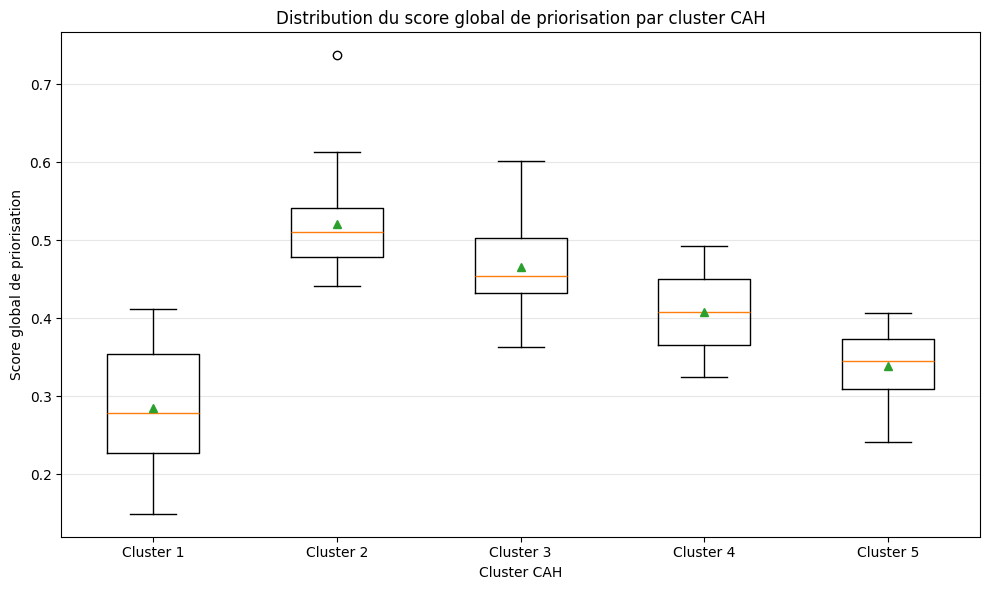

In [415]:
# Boxplot du score global de priorisation par cluster CAH

clusters_tries = sorted(base_cluster["cluster_cah"].unique())

donnees_boxplot = [
    base_cluster.loc[
        base_cluster["cluster_cah"] == cluster,
        "score_priorisation_global"]
    for cluster in clusters_tries]

plt.figure(figsize=(10, 6))

plt.boxplot(
    donnees_boxplot,
    tick_labels=[f"Cluster {int(cluster)}" for cluster in clusters_tries],
    showmeans=True)

plt.title("Distribution du score global de priorisation par cluster CAH")
plt.xlabel("Cluster CAH")
plt.ylabel("Score global de priorisation")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Le boxplot montre que le cluster 2 concentre globalement les scores de priorisation les plus élevés, ce qui confirme son intérêt pour la suite de l’analyse.

Le cluster 3 présente également certains pays intéressants, mais avec une distribution plus hétérogène. Les autres clusters apparaissent moins prioritaires pour une première stratégie d’exportation de poulet bio.

In [416]:
# Ajout d'un nom interprétable pour chaque cluster CAH

noms_clusters_cah = {
    1: "Marchés moins favorables",
    2: "Marchés attractifs et développés",
    3: "Marchés dépendants des importations",
    4: "Méga-marchés atypiques",
    5: "Marchés orientés production locale"}

base_cluster["profil_cluster_cah"] = base_cluster["cluster_cah"].map(noms_clusters_cah)

# Vérification
base_cluster[[col_pays, "cluster_cah", "profil_cluster_cah"]].head(10)

,pays,cluster_cah,profil_cluster_cah
0,Afghanistan,1,Marchés moins favorables
1,Afrique du Sud,3,Marchés dépendants des importations
2,Albanie,3,Marchés dépendants des importations
3,Algérie,1,Marchés moins favorables
4,Allemagne,2,Marchés attractifs et développés
5,Angola,1,Marchés moins favorables
6,Antigua-et-Barbuda,3,Marchés dépendants des importations
7,Arabie saoudite,3,Marchés dépendants des importations
8,Argentine,5,Marchés orientés production locale
9,Arménie,3,Marchés dépendants des importations


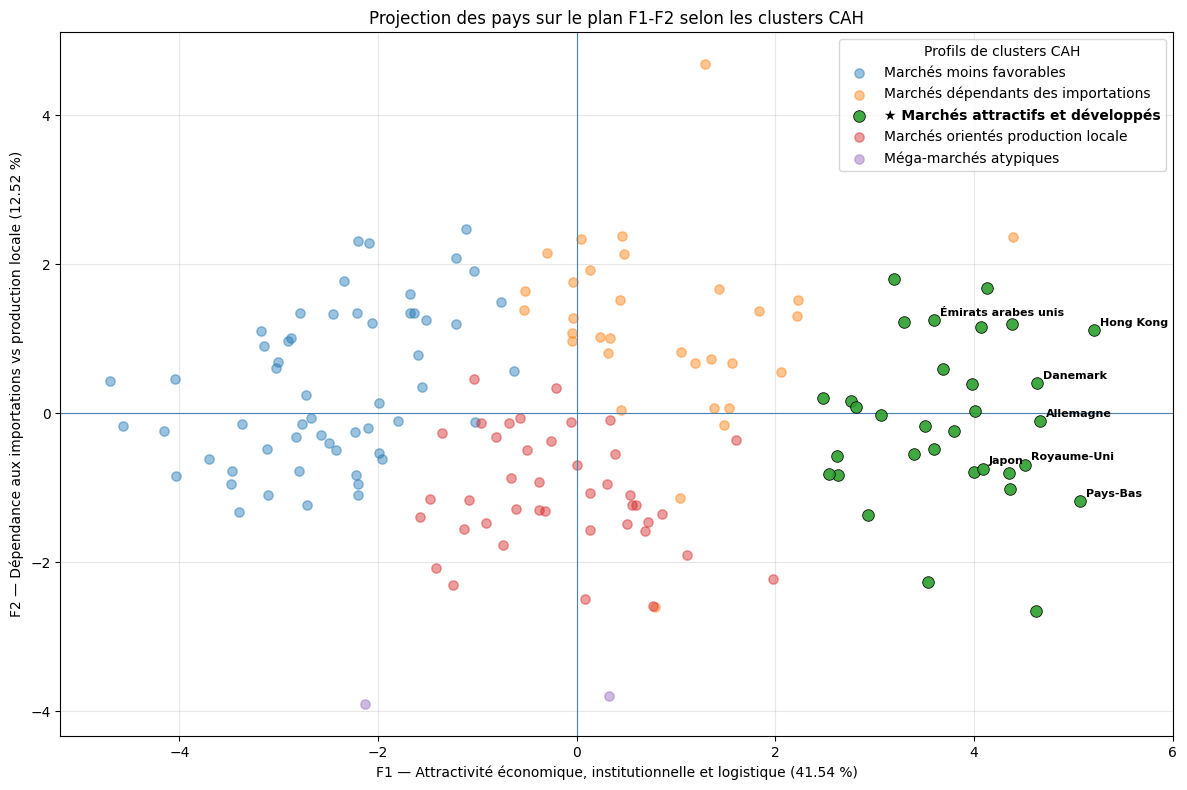

In [417]:
# Projection des pays sur le plan F1-F2 selon les clusters CAH
# Avec mise en évidence du cluster "Marchés attractifs et développés"

col_pays = "pays"

coord_pays_clusters = coord_pays.copy()
coord_pays_clusters[col_pays] = base_cluster[col_pays].values
coord_pays_clusters["cluster_cah"] = base_cluster["cluster_cah"].values
coord_pays_clusters["profil_cluster_cah"] = base_cluster["profil_cluster_cah"].values

plt.figure(figsize=(12, 8))

# Couleurs définies manuellement pour garder le cluster attractif en vert
couleurs_profils = {
    "Marchés moins favorables": "tab:blue",
    "Marchés dépendants des importations": "tab:orange",
    "Marchés attractifs et développés": "tab:green",
    "Marchés orientés production locale": "tab:red",
    "Méga-marchés atypiques": "tab:purple"}

# Tracé des clusters
for profil in coord_pays_clusters["profil_cluster_cah"].unique():
    subset = coord_pays_clusters[
        coord_pays_clusters["profil_cluster_cah"] == profil    ]
    
    if profil == "Marchés attractifs et développés":
        plt.scatter(
            subset["F1"],
            subset["F2"],
            label="★ Marchés attractifs et développés",
            alpha=0.9,
            s=70,
            edgecolor="black",
            linewidth=0.6,
            color=couleurs_profils[profil],
            zorder=3)
    else:
        plt.scatter(
            subset["F1"],
            subset["F2"],
            label=profil,
            alpha=0.45,
            s=45,
            color=couleurs_profils[profil],
            zorder=2)

# Axes
plt.axhline(0, color="steelblue", linewidth=0.8)
plt.axvline(0, color="steelblue", linewidth=0.8)

# Pays du nuage vert à annoter
pays_a_annoter = [
    "Chine - RAS de Hong-Kong",
    "Allemagne",
    "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord",
    "Japon",
    "Pays-Bas",
    "Émirats arabes unis",
    "Danemark"]

# Labels courts pour le graphique
labels_affichage = {
    "Chine - RAS de Hong-Kong": "Hong Kong",
    "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord": "Royaume-Uni",
    "Émirats arabes unis": "Émirats arabes unis"}

# Annotation des pays sélectionnés
for pays in pays_a_annoter:
    ligne = coord_pays_clusters[coord_pays_clusters[col_pays] == pays]
    
    if not ligne.empty:
        x = ligne["F1"].values[0]
        y = ligne["F2"].values[0]
        
        plt.text(
            x + 0.06,
            y + 0.06,
            labels_affichage.get(pays, pays),
            fontsize=8,
            fontweight="bold",
            color="black")

 # Ajustement des limites pour éviter que les labels soient coupés
        plt.xlim(-5.2, 6.0)           

# Titres et axes
plt.title("Projection des pays sur le plan F1-F2 selon les clusters CAH")

plt.xlabel(
    f"F1 — Attractivité économique, institutionnelle et logistique "
    f"({pca.explained_variance_ratio_[0]*100:.2f} %)")

plt.ylabel(
    f"F2 — Dépendance aux importations vs production locale "
    f"({pca.explained_variance_ratio_[1]*100:.2f} %)")

# Légende
legende = plt.legend(
    title="Profils de clusters CAH",
    loc="upper right",
    frameon=True)

# Mise en gras de la ligne du cluster attractif dans la légende
for texte in legende.get_texts():
    if "Marchés attractifs et développés" in texte.get_text():
        texte.set_fontweight("bold")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [418]:
# Tableau synthétique des profils de clusters CAH

table_profils_clusters = (
    base_cluster
    .groupby(["cluster_cah", "profil_cluster_cah"])
    .size()
    .reset_index(name="nb_pays")
    .rename(columns={
        "cluster_cah": "Cluster",
        "profil_cluster_cah": "Profil",
        "nb_pays": "Nb pays"}))

table_profils_clusters

,Cluster,Profil,Nb pays
0,1,Marchés moins favorables,56
1,2,Marchés attractifs et développés,32
2,3,Marchés dépendants des importations,32
3,4,Méga-marchés atypiques,2
4,5,Marchés orientés production locale,41


## Projection des clusters CAH sur le plan factoriel F1-F2

La projection des clusters issus de la CAH sur le plan factoriel F1-F2 confirme la cohérence de la segmentation obtenue.

Les **marchés moins favorables** se situent principalement à gauche du graphique, ce qui correspond à des scores plus faibles sur l’axe F1, associé à l’attractivité économique, institutionnelle et logistique.

Les **marchés attractifs et développés** sont concentrés à droite du graphique. Ils présentent donc un profil plus favorable en matière de niveau de développement économique, d’environnement institutionnel, de performance logistique et de facilité à faire des affaires.

Les **marchés dépendants des importations** se distinguent davantage sur l’axe F2. Ils représentent des pays dont le profil d’approvisionnement en volaille semble plus favorable à l’importation.

Les **marchés orientés production locale** se situent plutôt dans la partie inférieure du graphique. Ils présentent une production de volaille par habitant plus élevée et une dépendance aux importations plus faible, ce qui peut limiter leur intérêt pour une stratégie d’exportation.

Enfin, les **méga-marchés atypiques**, représentés par la Chine continentale et l’Inde, apparaissent isolés. Leur taille de marché très importante justifie de les traiter à part dans l’analyse.

Cette visualisation confirme que les clusters CAH permettent d’identifier des profils de pays cohérents et exploitables pour la suite de l’étude.

## Classification par k-means

Le k-means est appliqué comme une deuxième méthode de clustering, de manière indépendante de la CAH.

Il est réalisé sur les mêmes données d’entrée, c’est-à-dire les six premiers axes de l’ACP, afin de comparer ensuite les profils obtenus avec ceux de la CAH.

In [419]:
# Évaluation du nombre de clusters pour le k-means

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

resultats_kmeans = []

for k in range(2, 9):
    modele_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50)
    
    labels = modele_kmeans.fit_predict(X_clustering)
    
    resultats_kmeans.append({
        "nombre_clusters": k,
        "inertie": modele_kmeans.inertia_,
        "score_silhouette": silhouette_score(X_clustering, labels)})

resultats_kmeans = pd.DataFrame(resultats_kmeans)

resultats_kmeans

,nombre_clusters,inertie,score_silhouette
0,2,"1,234.21",0.35
1,3,"1,022.08",0.24
2,4,884.24,0.26
3,5,756.53,0.27
4,6,672.33,0.28
5,7,606.88,0.25
6,8,560.08,0.26


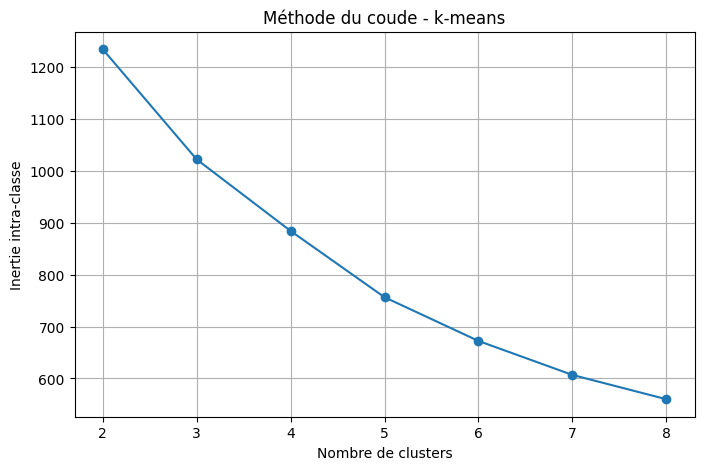

In [420]:
# Méthode du coude - inertie k-means

plt.figure(figsize=(8, 5))

plt.plot(
    resultats_kmeans["nombre_clusters"],
    resultats_kmeans["inertie"],
    marker="o")

plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie intra-classe")
plt.title("Méthode du coude - k-means")
plt.grid(True)

plt.show()

La courbe d’inertie diminue lorsque le nombre de clusters augmente. L’objectif est d’identifier un point de coude, c’est-à-dire un nombre de clusters à partir duquel le gain d’inertie devient moins important.

Cette analyse permet d’évaluer le nombre de clusters pour le k-means de manière indépendante.

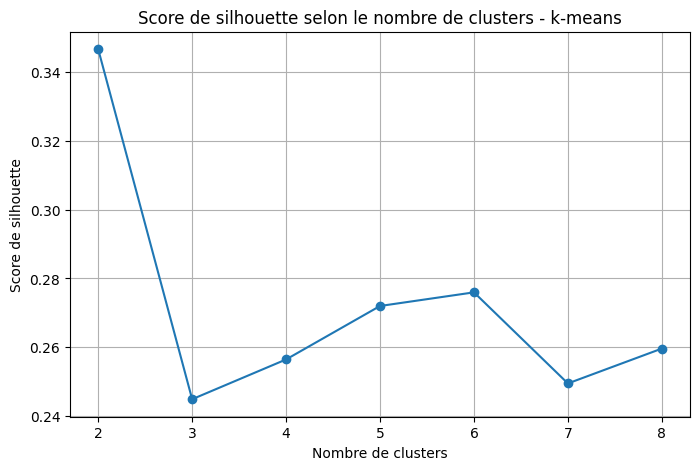

In [421]:
# Score de silhouette selon le nombre de clusters - k-means

plt.figure(figsize=(8, 5))

plt.plot(
    resultats_kmeans["nombre_clusters"],
    resultats_kmeans["score_silhouette"],
    marker="o")

plt.xlabel("Nombre de clusters")
plt.ylabel("Score de silhouette")
plt.title("Score de silhouette selon le nombre de clusters - k-means")
plt.grid(True)

plt.show()

Le score de silhouette est plus élevé pour une solution à 2 clusters, mais cette segmentation reste trop générale pour une étude de marché.

Parmi les solutions plus détaillées, les scores pour 5 et 6 clusters restent proches. Une solution à 5 clusters est retenue pour le k-means afin de garder une segmentation lisible, cohérente avec la CAH et exploitable d’un point de vue métier.

In [422]:
# Classification finale par k-means avec 5 clusters

nombre_clusters_kmeans = 5

modele_kmeans = KMeans(
    n_clusters=nombre_clusters_kmeans,
    random_state=42,
    n_init=50)

labels_kmeans = modele_kmeans.fit_predict(X_clustering)

# Ajout des clusters k-means à la base
base_cluster["cluster_kmeans"] = labels_kmeans + 1

# Vérification de la taille des clusters
base_cluster["cluster_kmeans"].value_counts().sort_index()

cluster_kmeans
1     2
2    43
3    42
4    44
5    32
Name: count, dtype: int64

In [423]:
# Pays du petit cluster k-means

base_cluster.loc[
    base_cluster["cluster_kmeans"] == 1,
    ["pays", "cluster_cah", "cluster_kmeans"]].sort_values("pays")

,pays,cluster_cah,cluster_kmeans
32,"Chine, continentale",4,1
63,Inde,4,1


Le k-means identifie également un petit cluster composé de la Chine continentale et de l’Inde. 

Ce résultat est cohérent avec la CAH, qui isolait déjà ces deux pays dans le cluster des méga-marchés atypiques. Cela montre que ce profil très spécifique est retrouvé par les deux méthodes de clustering.

In [424]:
# Comparaison des clusters CAH et k-means

comparaison_cah_kmeans = pd.crosstab(
    base_cluster["cluster_cah"],
    base_cluster["cluster_kmeans"],
    rownames=["Cluster CAH"],
    colnames=["Cluster k-means"])

comparaison_cah_kmeans

Cluster k-means,1,2,3,4,5
Cluster CAH,,,,,
1,0,0,1,41,14
2,0,32,0,0,0
3,0,11,3,0,18
4,2,0,0,0,0
5,0,0,38,3,0


## Comparaison entre la CAH et le k-means

La CAH et le k-means ont été appliqués indépendamment sur les mêmes données d’entrée : les six premiers axes de l’ACP.

Les numéros de clusters ne sont pas directement comparables entre les deux méthodes, car chaque algorithme attribue ses propres labels. La comparaison porte donc sur la composition des groupes et sur les profils de pays obtenus.

La comparaison montre que plusieurs profils restent stables entre les deux méthodes :

- le cluster CAH 2 est entièrement retrouvé dans le k-means, avec 32 pays sur 32 ;
- le cluster CAH 4, composé de la Chine continentale et de l’Inde, est également isolé par le k-means ;
- le cluster CAH 5 est très majoritairement retrouvé dans le k-means, avec 38 pays sur 41.

En revanche, les clusters CAH 1 et 3 sont plus dispersés entre plusieurs clusters k-means, ce qui indique des profils de pays plus hétérogènes.

Après comparaison, la segmentation issue de la CAH est conservée comme segmentation principale pour la priorisation, car elle offre une lecture plus progressive et plus facilement interprétable grâce au dendrogramme. Le k-means permet de comparer cette segmentation avec une méthode de partitionnement différente.

In [425]:
# Liste des pays par cluster CAH - segmentation retenue

for cluster in sorted(base_cluster["cluster_cah"].unique()):
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster} - {noms_clusters_cah[cluster]}")
    print(f"{'='*60}")
    
    pays_cluster = (
        base_cluster.loc[
            base_cluster["cluster_cah"] == cluster,
            col_pays]
        .sort_values()
        .tolist())
    
    print(", ".join(pays_cluster))


CLUSTER 1 - Marchés moins favorables
Afghanistan, Algérie, Angola, Bangladesh, Burkina Faso, Bénin, Cabo Verde, Cambodge, Cameroun, Congo, Côte d'Ivoire, Djibouti, Eswatini, Gabon, Gambie, Ghana, Guinée, Guinée-Bissau, Haïti, Iraq, Kenya, Kirghizistan, Kiribati, Lesotho, Libéria, Madagascar, Malawi, Maldives, Mali, Mauritanie, Mozambique, Myanmar, Niger, Nigéria, Ouganda, Pakistan, Rwanda, République centrafricaine, République-Unie de Tanzanie, Sao Tomé-et-Principe, Sierra Leone, Soudan, Suriname, Sénégal, Tadjikistan, Tchad, Timor-Leste, Togo, Vanuatu, Venezuela (République bolivarienne du), Yémen, Zambie, Zimbabwe, Égypte, Éthiopie, Îles Salomon

CLUSTER 2 - Marchés attractifs et développés
Allemagne, Australie, Autriche, Belgique, Canada, Chili, Chine - RAS de Hong-Kong, Danemark, Espagne, Estonie, Finlande, France, Hongrie, Irlande, Islande, Israël, Italie, Japon, Lituanie, Norvège, Nouvelle-Zélande, Pays-Bas, Pologne, Portugal, Royaume-Uni de Grande-Bretagne et d'Irlande du Nord,

## Analyse des groupes de pays

La liste des pays par cluster permet de mieux comprendre la composition des groupes identifiés par la CAH.

Le **cluster 2**, composé de marchés attractifs et développés, regroupe des pays présentant un environnement économique, institutionnel et logistique favorable. Il constitue une première base intéressante pour identifier des marchés premium potentiels.

Le **cluster 3** rassemble des pays davantage dépendants des importations de volaille. Ce groupe est particulièrement pertinent pour une stratégie d’exportation, car ces marchés semblent plus ouverts aux produits étrangers.

Le **cluster 5** regroupe des pays davantage orientés vers la production locale de volaille. Leur dépendance aux importations est plus faible, ce qui peut limiter leur attractivité pour une stratégie d’exportation, malgré la présence de certains marchés importants.

Le **cluster 1** présente un profil globalement moins favorable, tandis que le **cluster 4**, composé de la Chine continentale et de l’Inde, correspond à des méga-marchés atypiques qui nécessiteraient une analyse spécifique.

Pour la suite de l’étude, l’analyse se concentrera principalement sur les **clusters 2 et 3**, qui combinent attractivité structurelle et/ou ouverture potentielle aux importations.

In [426]:
# Sélection des pays candidats pour la recommandation finale

clusters_candidats = [2, 3]

pays_candidats = base_cluster[
    base_cluster["cluster_cah"].isin(clusters_candidats)].copy()

print("Nombre de pays candidats :", pays_candidats.shape[0])

pays_candidats[[col_pays, "cluster_cah", "profil_cluster_cah"]].sort_values(
    ["cluster_cah", col_pays])

Nombre de pays candidats : 64


,pays,cluster_cah,profil_cluster_cah
4,Allemagne,2,Marchés attractifs et développés
10,Australie,2,Marchés attractifs et développés
11,Autriche,2,Marchés attractifs et développés
16,Belgique,2,Marchés attractifs et développés
29,Canada,2,Marchés attractifs et développés
...,...,...,...
126,Saint-Vincent-et-les Grenadines,3,Marchés dépendants des importations
127,Sainte-Lucie,3,Marchés dépendants des importations
128,Samoa,3,Marchés dépendants des importations
132,Slovaquie,3,Marchés dépendants des importations


## Construction du score de priorisation

Afin de classer les pays candidats, un score de priorisation est construit à partir de trois dimensions complémentaires : le potentiel de marché, l’ouverture aux importations et l’attractivité structurelle.

Ce score ne constitue pas un résultat statistique automatique : il s’agit d’un outil d’aide à la décision construit à partir d’hypothèses métier. Les pondérations retenues correspondent à un scénario de référence cohérent avec l’objectif de l’étude : identifier les marchés les plus pertinents pour une stratégie d’exportation de poulet bio.

Deux dimensions sont légèrement privilégiées :

- le potentiel de marché, car un pays cible doit représenter un volume commercial suffisant ;
- l’ouverture aux importations, car l’entreprise cherche à exporter et doit donc cibler des pays déjà ouverts ou dépendants de l’offre extérieure.

L’attractivité structurelle reste fortement prise en compte, car elle permet d’intégrer les conditions de faisabilité et de sécurisation du marché : pouvoir d’achat, urbanisation, stabilité politique, qualité réglementaire, performance logistique, environnement des affaires et dimension bio.

Les pondérations retenues sont donc les suivantes :

- 35 % pour le potentiel de marché ;
- 35 % pour l’ouverture aux importations ;
- 30 % pour l’attractivité structurelle.

Ces pondérations peuvent être ajustées dans une étude complémentaire selon les priorités stratégiques de l’entreprise. Elles doivent donc être interprétées comme un choix méthodologique assumé, et non comme une vérité absolue.

In [427]:
# Création d'un score de priorisation des pays candidats

from sklearn.preprocessing import MinMaxScaler

# Copie de travail
ranking_pays = pays_candidats.copy()

# Fonction de normalisation entre 0 et 1
def normaliser_serie(serie):
    scaler = MinMaxScaler()
    return scaler.fit_transform(serie.values.reshape(-1, 1)).flatten()

# Normalisation des variables utiles
ranking_pays["score_population"] = normaliser_serie(ranking_pays["population_2017"])
ranking_pays["score_dispo_volaille"] = normaliser_serie(ranking_pays["dispo_kg_hab_volaille"])
ranking_pays["score_importations"] = normaliser_serie(ranking_pays["importations_volaille"])

ranking_pays["score_dependance_import"] = normaliser_serie(ranking_pays["dependance_importation_volaille"])

# Pour les droits de douane : plus ils sont faibles, meilleur est le score
ranking_pays["score_droits_douane"] = 1 - normaliser_serie(ranking_pays["droit_douane_poulet_moyen_pct"])

ranking_pays["score_cout_import"] = normaliser_serie(ranking_pays["score_cout_import_moyen"])

ranking_pays["score_pib"] = normaliser_serie(ranking_pays["pib_habitant_ppa"])
ranking_pays["score_urbanisation"] = normaliser_serie(ranking_pays["population_urbaine_pct"])
ranking_pays["score_stabilite"] = normaliser_serie(ranking_pays["stabilite_politique"])
ranking_pays["score_reglementation"] = normaliser_serie(ranking_pays["qualite_reglementaire"])
ranking_pays["score_logistique"] = normaliser_serie(ranking_pays["performance_logistique"])
ranking_pays["score_business"] = normaliser_serie(ranking_pays["doing_business_score"])
ranking_pays["score_bio"] = normaliser_serie(ranking_pays["part_terres_arables_bio_pct"])

# Scores intermédiaires
ranking_pays["score_potentiel_marche"] = ranking_pays[
    ["score_population", "score_dispo_volaille", "score_importations"]].mean(axis=1)

ranking_pays["score_ouverture_import"] = ranking_pays[
    ["score_dependance_import", "score_droits_douane", "score_cout_import"]].mean(axis=1)

ranking_pays["score_attractivite_structurelle"] = ranking_pays[
    [
        "score_pib",
        "score_urbanisation",
        "score_stabilite",
        "score_reglementation",
        "score_logistique",
        "score_business",
        "score_bio"]].mean(axis=1)

# Score final pondéré
ranking_pays["score_priorisation"] = (
    0.35 * ranking_pays["score_potentiel_marche"] +
    0.35 * ranking_pays["score_ouverture_import"] +
    0.30 * ranking_pays["score_attractivite_structurelle"])

# Classement final
ranking_pays = ranking_pays.sort_values("score_priorisation", ascending=False)

ranking_pays[[
        col_pays,
        "profil_cluster_cah",
        "score_potentiel_marche",
        "score_ouverture_import",
        "score_attractivite_structurelle",
        "score_priorisation"]].head(15).round(3)

,pays,profil_cluster_cah,score_potentiel_marche,score_ouverture_import,score_attractivite_structurelle,score_priorisation
31,Chine - RAS de Hong-Kong,Marchés attractifs et développés,0.53,0.94,0.71,0.73
4,Allemagne,Marchés attractifs et développés,0.43,0.77,0.66,0.62
160,États-Unis d'Amérique,Marchés attractifs et développés,0.62,0.61,0.60,0.61
118,Royaume-Uni de Grande-Bretagne et d'Irlande du...,Marchés attractifs et développés,0.45,0.75,0.62,0.61
72,Japon,Marchés attractifs et développés,0.54,0.66,0.62,0.60
84,Luxembourg,Marchés dépendants des importations,0.08,0.98,0.69,0.58
112,Pays-Bas,Marchés attractifs et développés,0.29,0.77,0.66,0.57
158,Émirats arabes unis,Marchés attractifs et développés,0.34,0.76,0.60,0.57
39,Danemark,Marchés attractifs et développés,0.17,0.80,0.70,0.55
48,France,Marchés attractifs et développés,0.32,0.73,0.54,0.53


In [428]:
# Détail des 20 premiers pays du classement

colonnes_detail_ranking = [
    col_pays,
    "profil_cluster_cah",
    "population_2017",
    "dispo_kg_hab_volaille",
    "importations_volaille",
    "dependance_importation_volaille",
    "pib_habitant_ppa",
    "performance_logistique",
    "droit_douane_poulet_moyen_pct",
    "doing_business_score",
    "score_potentiel_marche",
    "score_ouverture_import",
    "score_attractivite_structurelle",
    "score_priorisation"]

ranking_pays[colonnes_detail_ranking].head(20).round(2)

,pays,profil_cluster_cah,population_2017,dispo_kg_hab_volaille,importations_volaille,dependance_importation_volaille,pib_habitant_ppa,performance_logistique,droit_douane_poulet_moyen_pct,doing_business_score,score_potentiel_marche,score_ouverture_import,score_attractivite_structurelle,score_priorisation
31,Chine - RAS de Hong-Kong,Marchés attractifs et développés,"7,306,322.00",53.51,907.00,97.42,"59,260.91",3.92,0.00,84.76,0.53,0.93,0.71,0.73
4,Allemagne,Marchés attractifs et développés,"82,658,409.00",19.47,842.00,35.74,"54,110.25",4.20,3.20,79.55,0.43,0.77,0.66,0.62
160,États-Unis d'Amérique,Marchés attractifs et développés,"325,084,756.00",55.68,123.00,0.56,"60,047.72",3.89,0.00,85.01,0.63,0.61,0.60,0.61
118,Royaume-Uni de Grande-Bretagne et d'Irlande du...,Marchés attractifs et développés,"66,727,461.00",31.94,779.00,30.04,"46,113.02",3.99,3.20,83.34,0.45,0.75,0.62,0.61
72,Japon,Marchés attractifs et développés,"127,502,725.00",18.50,"1,069.00",32.55,"41,444.22",4.03,10.45,77.65,0.54,0.66,0.62,0.61
84,Luxembourg,Marchés dépendants des importations,"591,910.00",18.33,11.00,100.00,"114,985.84",3.63,3.20,69.17,0.08,0.99,0.69,0.58
112,Pays-Bas,Marchés attractifs et développés,"17,021,347.00",20.33,608.00,35.60,"56,037.57",4.02,3.20,75.57,0.29,0.77,0.66,0.57
158,Émirats arabes unis,Marchés attractifs et développés,"9,487,203.00",43.47,433.00,90.02,"70,281.89",3.96,5.00,77.43,0.34,0.76,0.60,0.57
39,Danemark,Marchés attractifs et développés,"5,732,274.00",28.98,133.00,43.46,"55,271.60",3.99,3.20,84.60,0.17,0.80,0.70,0.55
48,France,Marchés attractifs et développés,"64,842,509.00",22.90,506.00,22.43,"44,469.15",3.84,3.20,76.25,0.32,0.73,0.54,0.53


Ce premier classement correspond au score brut calculé sur les pays candidats, avant l’application des filtres business.

Certains pays bien classés à ce stade peuvent donc être exclus ensuite, par exemple la France, les pays peu dépendants des importations ou les marchés ne répondant pas aux critères opérationnels retenus.

## Filtrage business des marchés prioritaires

Après le classement des pays candidats, un filtre business est appliqué afin de retenir les marchés les plus pertinents pour une première phase d’exportation.

La France est exclue, car elle ne constitue pas un marché d’exportation international pour une entreprise française. Les pays de moins d’un million d’habitants sont également exclus de la sélection principale afin d’éviter de prioriser des micro-marchés.

Enfin, seuls les pays présentant un score de priorisation supérieur ou égal à 0,50 et une dépendance aux importations de volaille d’au moins 30 % sont retenus. Ce dernier critère permet d’écarter les marchés très attractifs structurellement mais peu ouverts aux importations de volaille.

Cette étape permet d’obtenir une shortlist plus opérationnelle et plus adaptée à une recommandation stratégique pour le COMEX.

In [429]:
# Premier filtre business : exclusion de la France et des micro-marchés

ranking_prioritaire = ranking_pays[
    (ranking_pays[col_pays] != "France") &
    (ranking_pays["population_2017"] >= 1_000_000)
].copy()

ranking_prioritaire[[
        col_pays,
        "profil_cluster_cah",
        "population_2017",
        "importations_volaille",
        "dependance_importation_volaille",
        "pib_habitant_ppa",
        "performance_logistique",
        "droit_douane_poulet_moyen_pct",
        "score_priorisation"]].head(15).round(2)

,pays,profil_cluster_cah,population_2017,importations_volaille,dependance_importation_volaille,pib_habitant_ppa,performance_logistique,droit_douane_poulet_moyen_pct,score_priorisation
31,Chine - RAS de Hong-Kong,Marchés attractifs et développés,"7,306,322.00",907.00,97.42,"59,260.91",3.92,0.00,0.73
4,Allemagne,Marchés attractifs et développés,"82,658,409.00",842.00,35.74,"54,110.25",4.20,3.20,0.62
160,États-Unis d'Amérique,Marchés attractifs et développés,"325,084,756.00",123.00,0.56,"60,047.72",3.89,0.00,0.61
118,Royaume-Uni de Grande-Bretagne et d'Irlande du...,Marchés attractifs et développés,"66,727,461.00",779.00,30.04,"46,113.02",3.99,3.20,0.61
72,Japon,Marchés attractifs et développés,"127,502,725.00","1,069.00",32.55,"41,444.22",4.03,10.45,0.61
112,Pays-Bas,Marchés attractifs et développés,"17,021,347.00",608.00,35.60,"56,037.57",4.02,3.20,0.57
158,Émirats arabes unis,Marchés attractifs et développés,"9,487,203.00",433.00,90.02,"70,281.89",3.96,5.00,0.57
39,Danemark,Marchés attractifs et développés,"5,732,274.00",133.00,43.46,"55,271.60",3.99,3.20,0.55
138,Suède,Marchés attractifs et développés,"9,904,896.00",84.00,34.85,"51,474.12",4.05,3.20,0.52
11,Autriche,Marchés attractifs et développés,"8,819,901.00",110.00,42.64,"53,869.83",4.03,3.20,0.52


In [430]:
# Filtre final : score minimum et dépendance aux importations

marches_prioritaires = ranking_prioritaire[
    (ranking_prioritaire["score_priorisation"] >= 0.50) &
    (ranking_prioritaire["dependance_importation_volaille"] >= 30)].copy()

marches_prioritaires[[
        col_pays,
        "profil_cluster_cah",
        "population_2017",
        "importations_volaille",
        "dependance_importation_volaille",
        "pib_habitant_ppa",
        "performance_logistique",
        "droit_douane_poulet_moyen_pct",
        "score_priorisation"]].round(2)

,pays,profil_cluster_cah,population_2017,importations_volaille,dependance_importation_volaille,pib_habitant_ppa,performance_logistique,droit_douane_poulet_moyen_pct,score_priorisation
31,Chine - RAS de Hong-Kong,Marchés attractifs et développés,"7,306,322.00",907.00,97.42,"59,260.91",3.92,0.00,0.73
4,Allemagne,Marchés attractifs et développés,"82,658,409.00",842.00,35.74,"54,110.25",4.20,3.20,0.62
118,Royaume-Uni de Grande-Bretagne et d'Irlande du...,Marchés attractifs et développés,"66,727,461.00",779.00,30.04,"46,113.02",3.99,3.20,0.61
72,Japon,Marchés attractifs et développés,"127,502,725.00","1,069.00",32.55,"41,444.22",4.03,10.45,0.61
112,Pays-Bas,Marchés attractifs et développés,"17,021,347.00",608.00,35.60,"56,037.57",4.02,3.20,0.57
158,Émirats arabes unis,Marchés attractifs et développés,"9,487,203.00",433.00,90.02,"70,281.89",3.96,5.00,0.57
39,Danemark,Marchés attractifs et développés,"5,732,274.00",133.00,43.46,"55,271.60",3.99,3.20,0.55
138,Suède,Marchés attractifs et développés,"9,904,896.00",84.00,34.85,"51,474.12",4.05,3.20,0.52
11,Autriche,Marchés attractifs et développés,"8,819,901.00",110.00,42.64,"53,869.83",4.03,3.20,0.52
16,Belgique,Marchés attractifs et développés,"11,419,748.00",338.00,42.20,"50,256.06",4.04,3.20,0.51


In [431]:
# Ajout d'un niveau de priorité à la shortlist finale

marches_prioritaires = marches_prioritaires.sort_values(
    "score_priorisation", ascending=False).copy()

marches_prioritaires["rang"] = range(1, len(marches_prioritaires) + 1)

marches_prioritaires["niveau_priorite"] = marches_prioritaires["rang"].apply(
    lambda x: "Priorité 1" if x <= 6 else "Priorité 2")

marches_prioritaires[[
        "rang",
        col_pays,
        "niveau_priorite",
        "profil_cluster_cah",
        "population_2017",
        "importations_volaille",
        "dependance_importation_volaille",
        "pib_habitant_ppa",
        "performance_logistique",
        "droit_douane_poulet_moyen_pct",
        "score_priorisation"]].round(2)

,rang,pays,niveau_priorite,profil_cluster_cah,population_2017,importations_volaille,dependance_importation_volaille,pib_habitant_ppa,performance_logistique,droit_douane_poulet_moyen_pct,score_priorisation
31,1,Chine - RAS de Hong-Kong,Priorité 1,Marchés attractifs et développés,"7,306,322.00",907.00,97.42,"59,260.91",3.92,0.00,0.73
4,2,Allemagne,Priorité 1,Marchés attractifs et développés,"82,658,409.00",842.00,35.74,"54,110.25",4.20,3.20,0.62
118,3,Royaume-Uni de Grande-Bretagne et d'Irlande du...,Priorité 1,Marchés attractifs et développés,"66,727,461.00",779.00,30.04,"46,113.02",3.99,3.20,0.61
72,4,Japon,Priorité 1,Marchés attractifs et développés,"127,502,725.00","1,069.00",32.55,"41,444.22",4.03,10.45,0.61
112,5,Pays-Bas,Priorité 1,Marchés attractifs et développés,"17,021,347.00",608.00,35.60,"56,037.57",4.02,3.20,0.57
158,6,Émirats arabes unis,Priorité 1,Marchés attractifs et développés,"9,487,203.00",433.00,90.02,"70,281.89",3.96,5.00,0.57
39,7,Danemark,Priorité 2,Marchés attractifs et développés,"5,732,274.00",133.00,43.46,"55,271.60",3.99,3.20,0.55
138,8,Suède,Priorité 2,Marchés attractifs et développés,"9,904,896.00",84.00,34.85,"51,474.12",4.05,3.20,0.52
11,9,Autriche,Priorité 2,Marchés attractifs et développés,"8,819,901.00",110.00,42.64,"53,869.83",4.03,3.20,0.52
16,10,Belgique,Priorité 2,Marchés attractifs et développés,"11,419,748.00",338.00,42.20,"50,256.06",4.04,3.20,0.51


## Sélection finale des marchés prioritaires

À partir du score de priorisation, une shortlist de marchés prioritaires a été établie. Cette sélection repose sur trois critères principaux : le potentiel de marché, l’ouverture aux importations et l’attractivité structurelle.

Un filtre business a également été appliqué afin d’exclure la France, qui ne constitue pas un marché d’exportation international pour une entreprise française, ainsi que les micro-marchés de moins d’un million d’habitants.

La sélection finale met en évidence deux niveaux de priorité.

Les marchés de **Priorité 1** sont : Hong Kong, l’Allemagne, le Royaume-Uni, le Japon, les Pays-Bas et les Émirats arabes unis. Ces pays combinent un bon niveau de développement économique, une performance logistique élevée, un volume d’importations significatif et/ou une dépendance importante aux importations de volaille.

Les marchés de **Priorité 2** sont : le Danemark, la Suède, l’Autriche, la Belgique et la Suisse. Ces pays présentent également un environnement économique et institutionnel favorable, mais leur potentiel de marché ou leurs volumes d’importation apparaissent plus limités que ceux des marchés de priorité 1.

Cette shortlist constitue une base solide pour orienter la stratégie d’exportation de l’entreprise. Les pays de priorité 1 pourraient faire l’objet d’une analyse commerciale plus approfondie, notamment sur la demande en produits biologiques, les circuits de distribution, les exigences sanitaires et la concurrence locale.

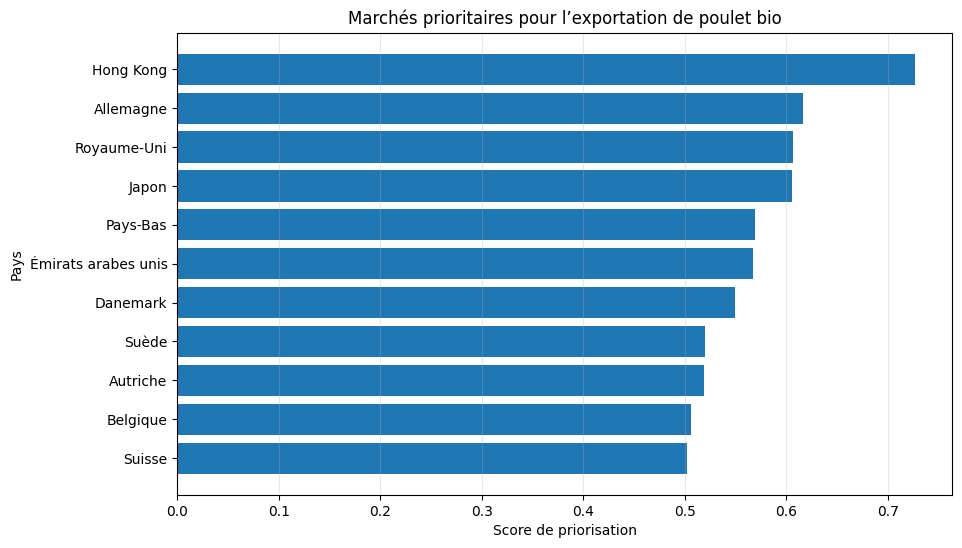

In [432]:
# Visualisation du score de priorisation des marchés sélectionnés

marches_plot = marches_prioritaires.copy()

# Abréviation de quelques noms longs pour améliorer la lisibilité
noms_abreges_final = {
    "Chine - RAS de Hong-Kong": "Hong Kong",
    "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord": "Royaume-Uni",
    "États-Unis d'Amérique": "États-Unis"}

marches_plot["nom_affiche"] = marches_plot[col_pays].replace(noms_abreges_final)

# Tri pour affichage du score le plus élevé en haut
marches_plot = marches_plot.sort_values("score_priorisation", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    marches_plot["nom_affiche"],
    marches_plot["score_priorisation"])

plt.xlabel("Score de priorisation")
plt.ylabel("Pays")
plt.title("Marchés prioritaires pour l’exportation de poulet bio")

plt.grid(axis="x", alpha=0.3)

plt.show()

## Visualisation des marchés prioritaires

Le graphique du score de priorisation permet de comparer visuellement les pays retenus dans la shortlist finale.

Hong Kong apparaît comme le marché le plus prioritaire, grâce à une très forte dépendance aux importations de volaille, des droits de douane nuls, un bon niveau de PIB par habitant et une bonne performance logistique.

L’Allemagne, le Royaume-Uni et le Japon présentent également des scores élevés. Ces pays combinent un potentiel de marché important, des volumes d’importation significatifs et un environnement économique et logistique favorable.

Les Pays-Bas et les Émirats arabes unis complètent les marchés de priorité 1. Les Pays-Bas se distinguent notamment par leur rôle de hub logistique européen, tandis que les Émirats arabes unis présentent une forte dépendance aux importations et un niveau de richesse élevé.

Les pays de priorité 2 — Danemark, Suède, Autriche, Belgique et Suisse — restent des marchés attractifs, mais avec un potentiel de marché ou des volumes d’importation plus limités.

Cette visualisation confirme donc la pertinence d’une stratégie en deux temps : cibler d’abord les marchés de priorité 1, puis étudier les marchés de priorité 2 comme opportunités complémentaires.

## Conclusion générale

Cette étude avait pour objectif d’identifier des groupes de pays pertinents pour orienter la stratégie d’exportation de poulet bio de l’entreprise *La poule qui chante*.

Dans un premier temps, une analyse en composantes principales a été réalisée à partir de 14 variables quantitatives décrivant le potentiel de marché, l’ouverture aux importations, l’environnement économique, la qualité institutionnelle, la performance logistique et le contexte agricole biologique des pays étudiés.

L’ACP a permis de réduire la dimensionnalité des données tout en conservant l’essentiel de l’information. Les deux premiers axes factoriels expliquent 54,06 % de la variance totale et ont permis de visualiser les grandes oppositions entre les pays. L’axe F1 traduit principalement l’attractivité économique, institutionnelle et logistique, tandis que l’axe F2 distingue les pays selon leur dépendance aux importations de volaille et leur niveau de production locale.

Dans un second temps, une classification ascendante hiérarchique a été réalisée à partir des six premiers axes de l’ACP, qui expliquent 82,93 % de la variance totale. Cette méthode a permis d’identifier cinq groupes de pays aux profils distincts : des marchés moins favorables, des marchés attractifs et développés, des marchés dépendants des importations, des méga-marchés atypiques et des marchés davantage orientés vers la production locale.

La comparaison avec l’algorithme k-means a montré que plusieurs profils restent stables entre les deux méthodes, notamment les marchés attractifs et développés, les méga-marchés atypiques composés de la Chine continentale et de l’Inde, ainsi que les marchés orientés vers la production locale.

Pour établir une recommandation finale, l’analyse s’est concentrée sur les clusters les plus pertinents pour une stratégie d’exportation : les marchés attractifs et développés ainsi que les marchés dépendants des importations. Un score de priorisation a ensuite été construit à partir de trois dimensions : le potentiel de marché, l’ouverture aux importations et l’attractivité structurelle.

Après application d’un filtre business, les marchés de priorité 1 identifiés sont : **Hong Kong, l’Allemagne, le Royaume-Uni, le Japon, les Pays-Bas et les Émirats arabes unis**. Ces pays combinent un environnement économique favorable, une bonne performance logistique, des volumes d’importation significatifs et/ou une forte dépendance aux importations de volaille.

Les marchés de priorité 2 sont : **le Danemark, la Suède, l’Autriche, la Belgique et la Suisse**. Ils présentent également un profil favorable, mais avec un potentiel de marché ou des volumes d’importation plus limités.

La recommandation principale est donc de cibler en priorité les marchés de priorité 1, tout en conservant les marchés de priorité 2 comme opportunités complémentaires. Une analyse plus approfondie devra ensuite être menée sur les aspects qualitatifs : demande réelle en produits biologiques, circuits de distribution, concurrence locale, exigences sanitaires, contraintes réglementaires et stratégie de positionnement prix.

## Limites de l’analyse

Cette analyse repose sur des données quantitatives disponibles pour 163 pays. Malgré le travail de nettoyage et de préparation réalisé, certains indicateurs restent des approximations et peuvent ne pas refléter parfaitement la situation actuelle de chaque marché.

Le score de priorisation constitue un outil d’aide à la décision, mais il ne remplace pas une étude commerciale complète. Les pondérations retenues pour le potentiel de marché, l’ouverture aux importations et l’attractivité structurelle reposent sur des choix méthodologiques qui pourraient être ajustés selon la stratégie exacte de l’entreprise.

Par ailleurs, l’analyse ne prend pas en compte certains éléments qualitatifs importants, tels que les habitudes de consommation de produits biologiques, la notoriété des labels bio, les circuits de distribution, la concurrence locale, les exigences sanitaires spécifiques ou encore les préférences culturelles des consommateurs.

Les résultats doivent donc être considérés comme une première étape de ciblage. Les pays identifiés comme prioritaires devront faire l’objet d’une analyse complémentaire avant toute décision d’implantation ou d’exportation.

In [433]:
# Export de la table finale des marchés prioritaires

table_finale_recommandation = marches_prioritaires[
    [
        "rang",
        col_pays,
        "niveau_priorite",
        "profil_cluster_cah",
        "population_2017",
        "importations_volaille",
        "dependance_importation_volaille",
        "pib_habitant_ppa",
        "performance_logistique",
        "droit_douane_poulet_moyen_pct",
        "score_priorisation"]].copy()

# Renommage des colonnes pour une lecture plus claire
table_finale_recommandation = table_finale_recommandation.rename(columns={
    col_pays: "pays",
    "population_2017": "population",
    "importations_volaille": "importations_volaille",
    "dependance_importation_volaille": "dependance_importation_volaille_pct",
    "pib_habitant_ppa": "pib_habitant_ppa",
    "performance_logistique": "performance_logistique",
    "droit_douane_poulet_moyen_pct": "droit_douane_poulet_moyen_pct",
    "score_priorisation": "score_priorisation"})

# Export CSV
table_finale_recommandation.to_csv(
    "marches_prioritaires_poulet_bio.csv",
    index=False,
    encoding="utf-8-sig")

table_finale_recommandation.round(2)

,rang,pays,niveau_priorite,profil_cluster_cah,population,importations_volaille,dependance_importation_volaille_pct,pib_habitant_ppa,performance_logistique,droit_douane_poulet_moyen_pct,score_priorisation
31,1,Chine - RAS de Hong-Kong,Priorité 1,Marchés attractifs et développés,"7,306,322.00",907.00,97.42,"59,260.91",3.92,0.00,0.73
4,2,Allemagne,Priorité 1,Marchés attractifs et développés,"82,658,409.00",842.00,35.74,"54,110.25",4.20,3.20,0.62
118,3,Royaume-Uni de Grande-Bretagne et d'Irlande du...,Priorité 1,Marchés attractifs et développés,"66,727,461.00",779.00,30.04,"46,113.02",3.99,3.20,0.61
72,4,Japon,Priorité 1,Marchés attractifs et développés,"127,502,725.00","1,069.00",32.55,"41,444.22",4.03,10.45,0.61
112,5,Pays-Bas,Priorité 1,Marchés attractifs et développés,"17,021,347.00",608.00,35.60,"56,037.57",4.02,3.20,0.57
158,6,Émirats arabes unis,Priorité 1,Marchés attractifs et développés,"9,487,203.00",433.00,90.02,"70,281.89",3.96,5.00,0.57
39,7,Danemark,Priorité 2,Marchés attractifs et développés,"5,732,274.00",133.00,43.46,"55,271.60",3.99,3.20,0.55
138,8,Suède,Priorité 2,Marchés attractifs et développés,"9,904,896.00",84.00,34.85,"51,474.12",4.05,3.20,0.52
11,9,Autriche,Priorité 2,Marchés attractifs et développés,"8,819,901.00",110.00,42.64,"53,869.83",4.03,3.20,0.52
16,10,Belgique,Priorité 2,Marchés attractifs et développés,"11,419,748.00",338.00,42.20,"50,256.06",4.04,3.20,0.51
